# **Heart Disease Prediction using the following models:**

**1. Logistic Regression**

**2. KNN**

**3. XGBoostClassifier**

### **The Framingham Heart Study (FHS) dataset contains 16 columns representing patient demographics, medical history, and clinical measurements.**

**1. Patient Demographics:**

**Male:** Binary (1 = Male; 0 = Female).

**Age:** Continuous; the age of the patient in years.

**Education:** Categorical (1-4); levels typically ranging from some high school to a college degree.

**2. Behavioral Factors:**

**Current Smoker:** Binary (1 = Current smoker; 0 = Non-smoker).

**Cigs Per Day:** Continuous; average number of cigarettes smoked daily.

**3. Medical History:**

**BP Meds:** Binary (1 = On blood pressure medication; 0 = Not).

**Prevalent Stroke:** Binary (1 = Patient previously had a stroke; 0 = No).

**Prevalent Hyp:** Binary (1 = Patient was hypertensive; 0 = No).

**Diabetes:** Binary (1 = Patient has diabetes; 0 = No).

**4. Clinical Measurements:**

**Tot Chol:** Continuous; total cholesterol level in mg/dL.

**Sys BP:** Continuous; systolic blood pressure (top number).

**Dia BP:** Continuous; diastolic blood pressure (bottom number).

**BMI:** Continuous; Body Mass Index ((weight/height)^2).

**Heart Rate:** Continuous; beats per minute.

**Glucose:** Continuous; blood glucose level in mg/dL.

**5. Target Variable:**

**TenYearCHD:** Binary (1 = Developed coronary heart disease within 10 years; 0 = Did not).

In [67]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [68]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [69]:
# Print the last 5 rows
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [70]:
# Print the shape of the dataframe
df.shape

(4240, 16)

In [71]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [72]:
# Data type of the attributes of the dataframe
df.dtypes

,0
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64


In [73]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [74]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [75]:
df.keys()

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [76]:
df.nunique()

,0
male,2
age,39
education,4
currentSmoker,2
cigsPerDay,33
BPMeds,2
prevalentStroke,2
prevalentHyp,2
diabetes,2
totChol,248


In [77]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
male,0,0.000000
age,0,0.000000
education,105,2.476415
currentSmoker,0,0.000000
cigsPerDay,29,0.683962
BPMeds,53,1.250000
prevalentStroke,0,0.000000
prevalentHyp,0,0.000000
diabetes,0,0.000000
totChol,50,1.179245


# **Exploratory Data Analysis:**

In [78]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [80]:
# Target variable distribution
df["TenYearCHD"].value_counts()

,count
TenYearCHD,
0,3596
1,644


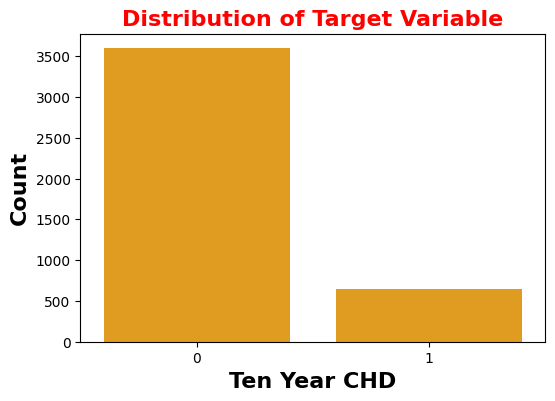

In [82]:
# Target variable distribution
plt.figure(figsize = (6,4))
sns.countplot(x = df['TenYearCHD'], color = 'orange')
plt.title('Distribution of Target Variable', fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel('Ten Year CHD', fontsize = 16, fontweight = 'bold')
plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
plt.show()

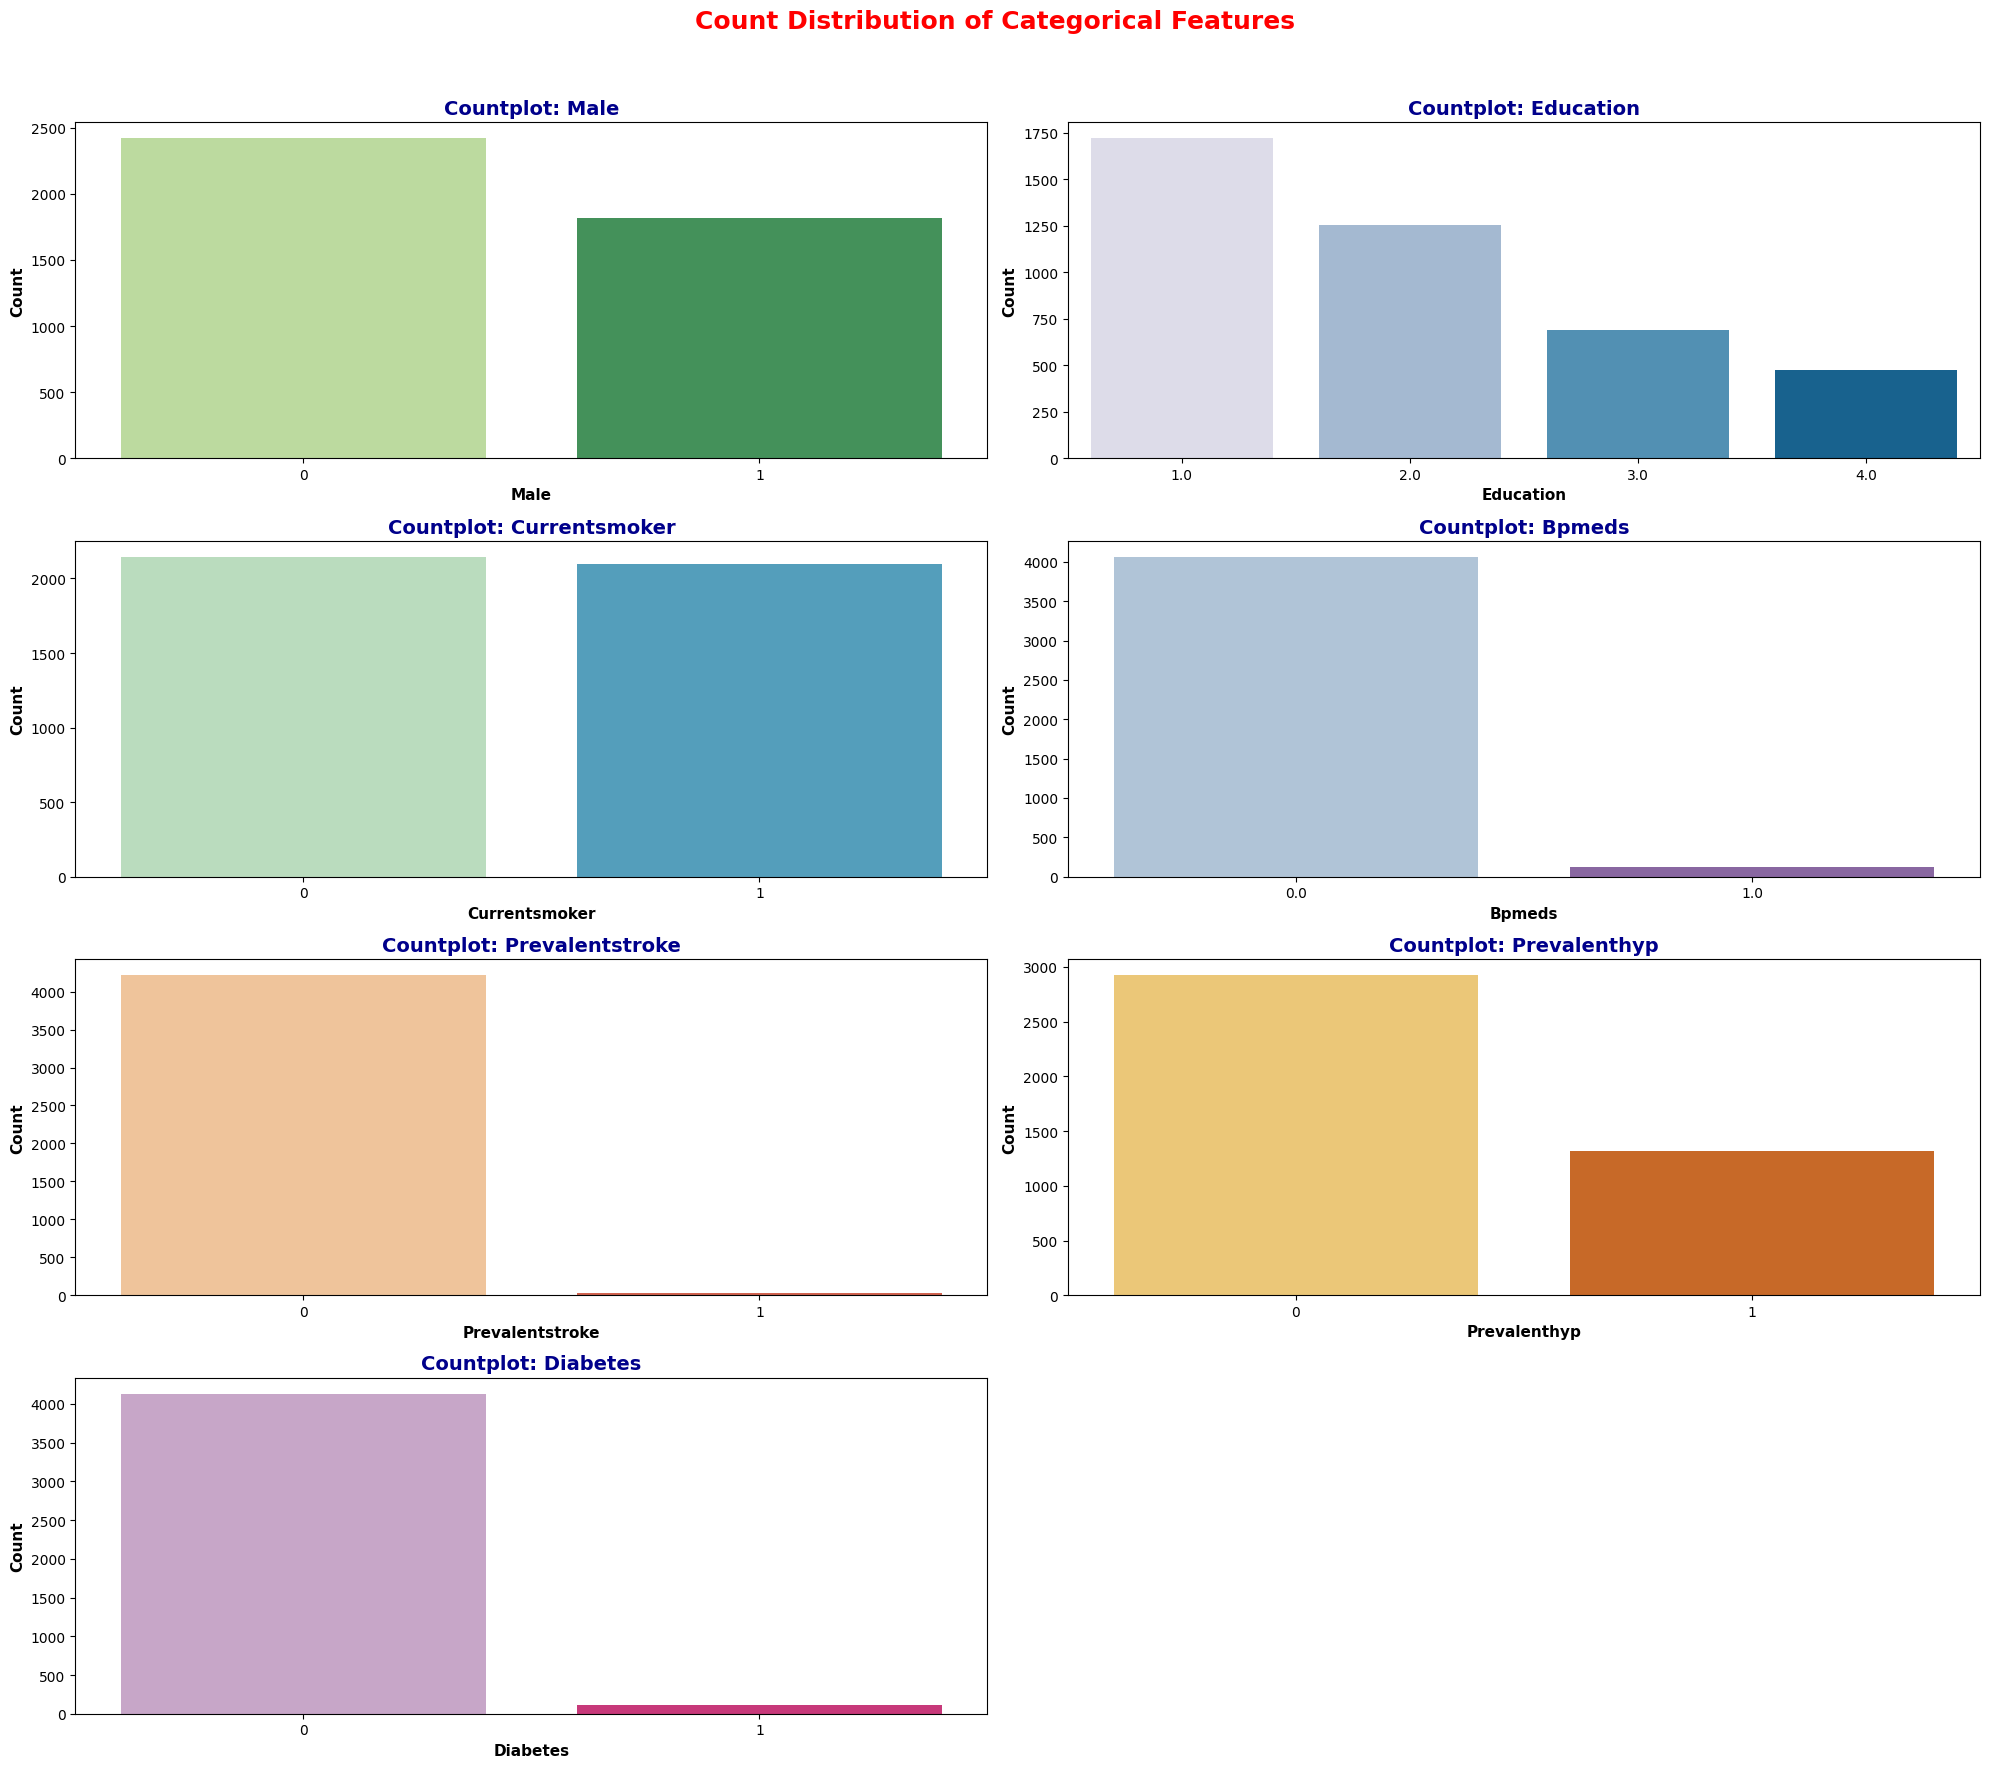

In [94]:
# Countplot of Categorical Features
cat_features = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

# Color palettes for each subplot
color_palettes = ['YlGn', 'PuBu', 'GnBu', 'BuPu', 'OrRd', 'YlOrBr', 'PuRd']

# 4 rows × 2 columns grid
fig, axes = plt.subplots(4, 2, figsize = (20, 18))
axes = axes.flatten()

for ax, feature, palette in zip(axes, cat_features, color_palettes):
    sns.countplot(data = df, x = feature, ax = ax, palette = palette)
    ax.set_title(f'Countplot: {feature.replace("_", " ").title()}', fontsize = 14, fontweight = 'bold', color = 'darkblue')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize = 11, fontweight = 'bold')
    ax.set_ylabel('Count', fontsize = 11, fontweight = 'bold')
    ax.tick_params(axis = 'x')

# Hide unused subplots if any
for ax in axes[len(cat_features):]:
    ax.set_visible(False)

plt.suptitle('Count Distribution of Categorical Features', fontsize = 18, fontweight = 'bold', color = 'red')
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

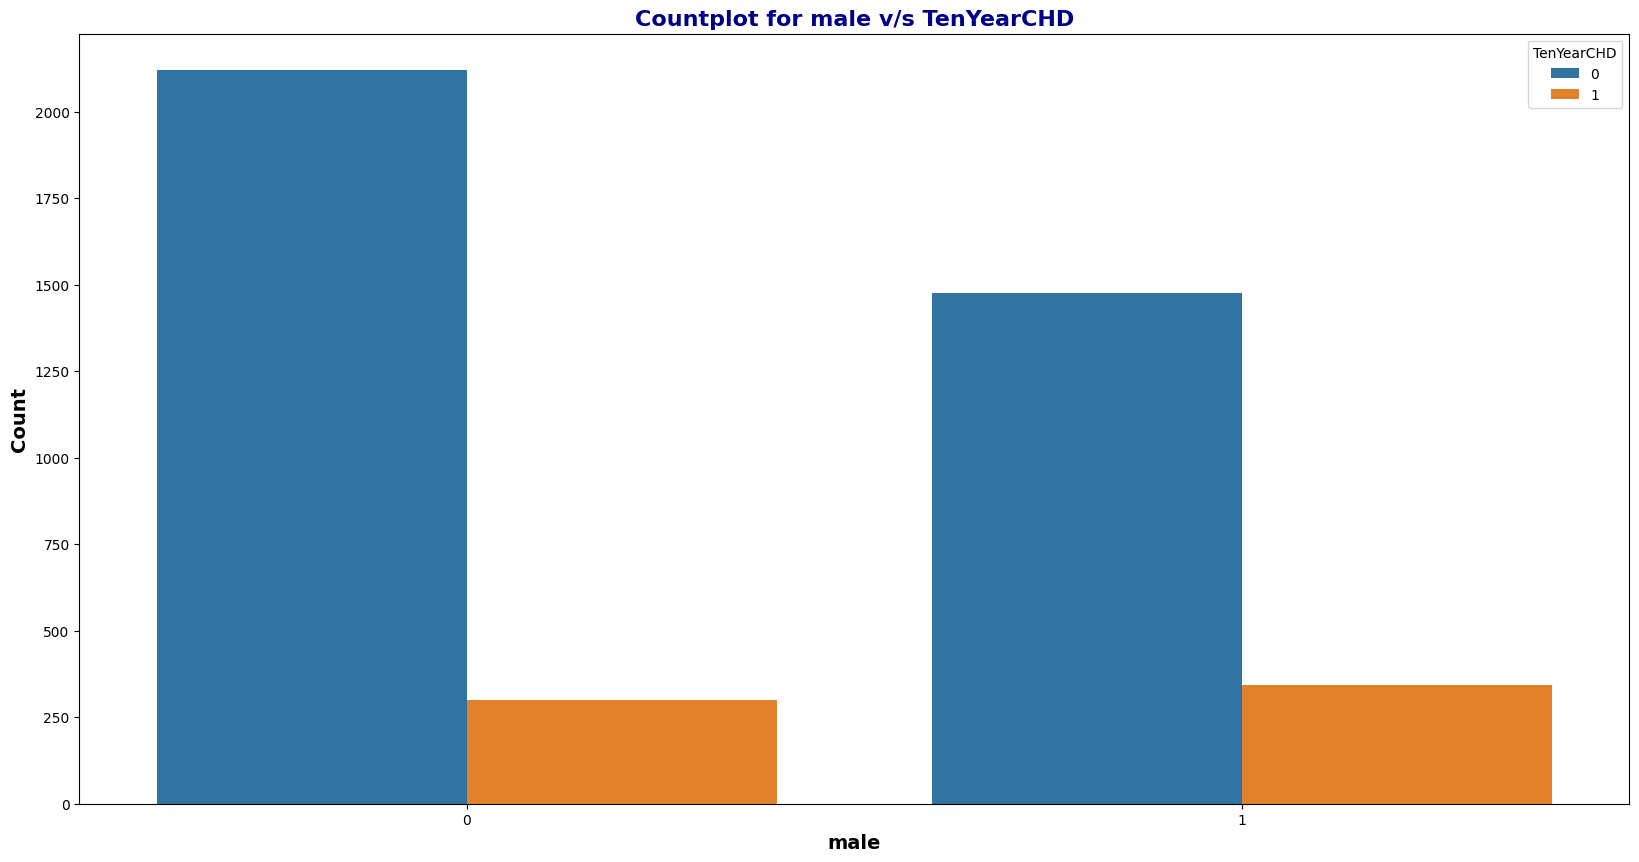

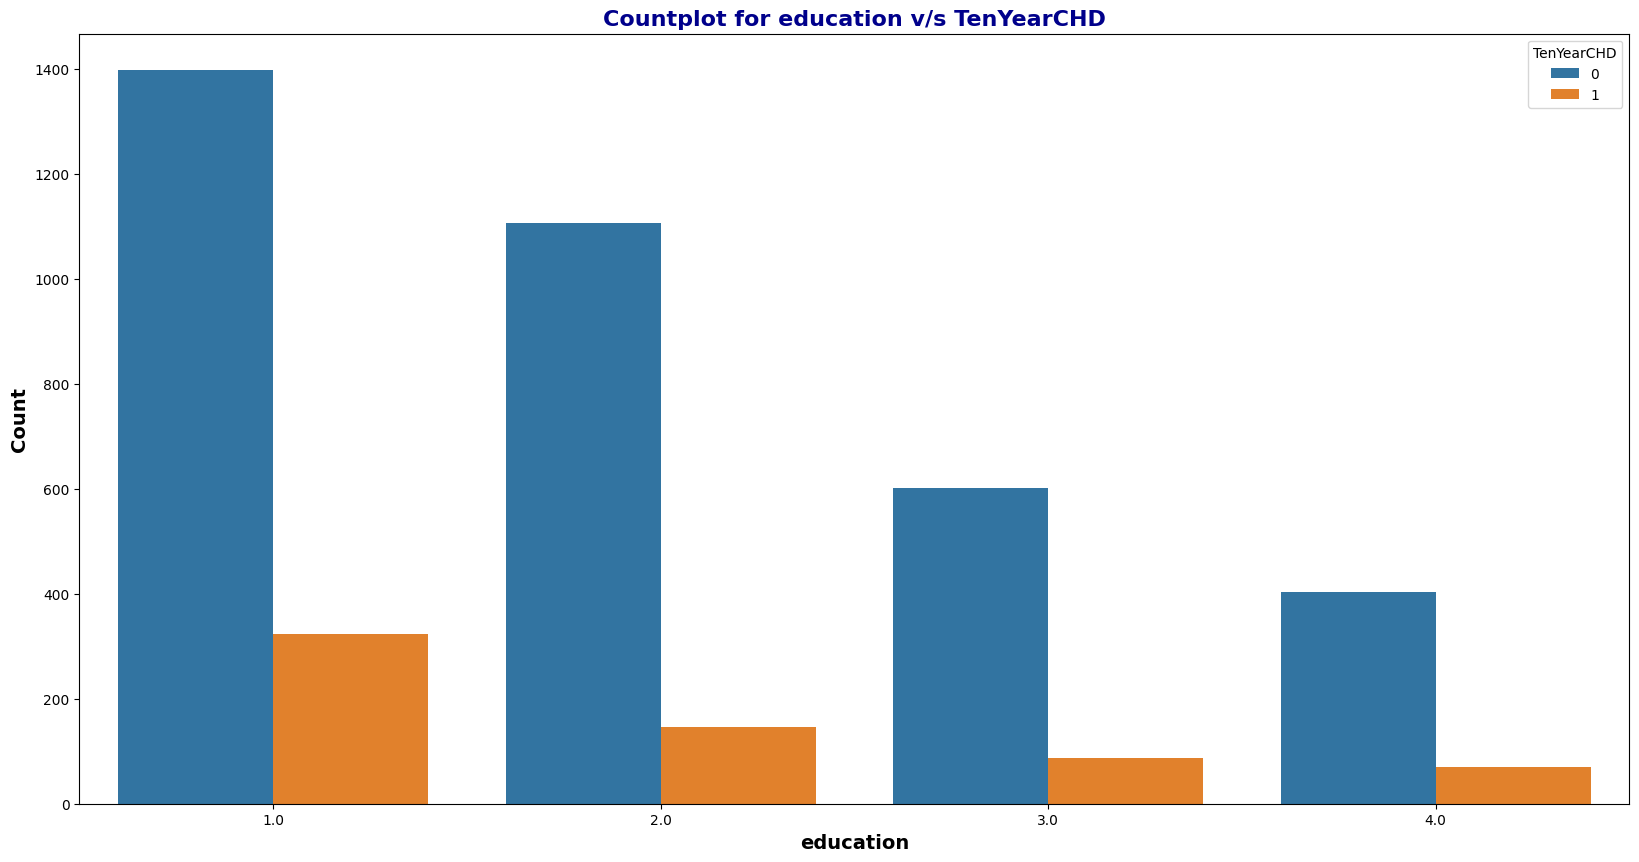

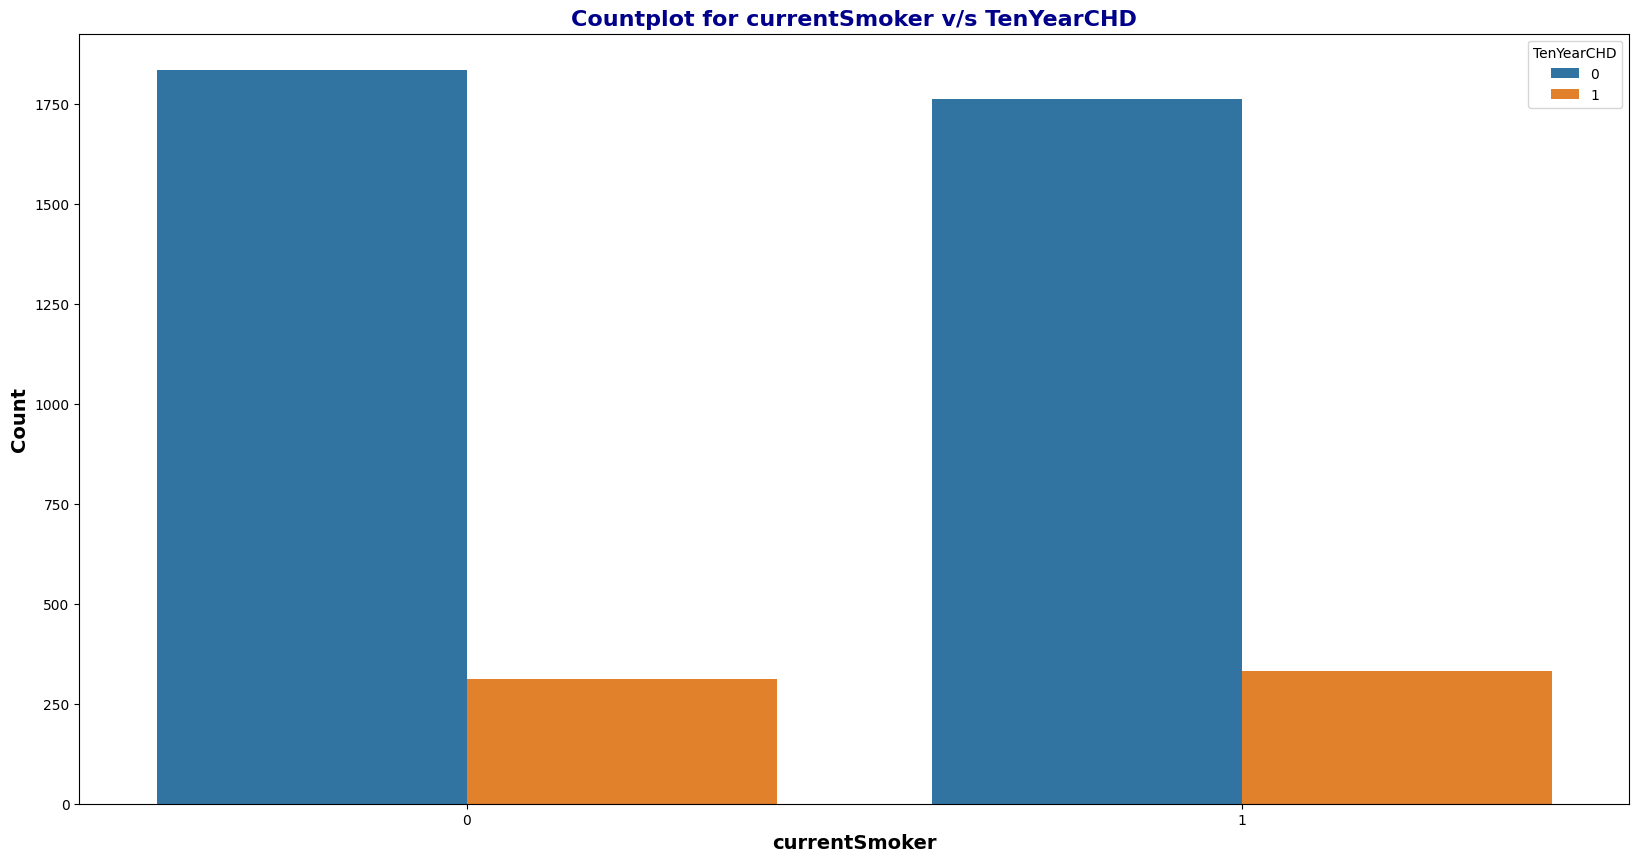

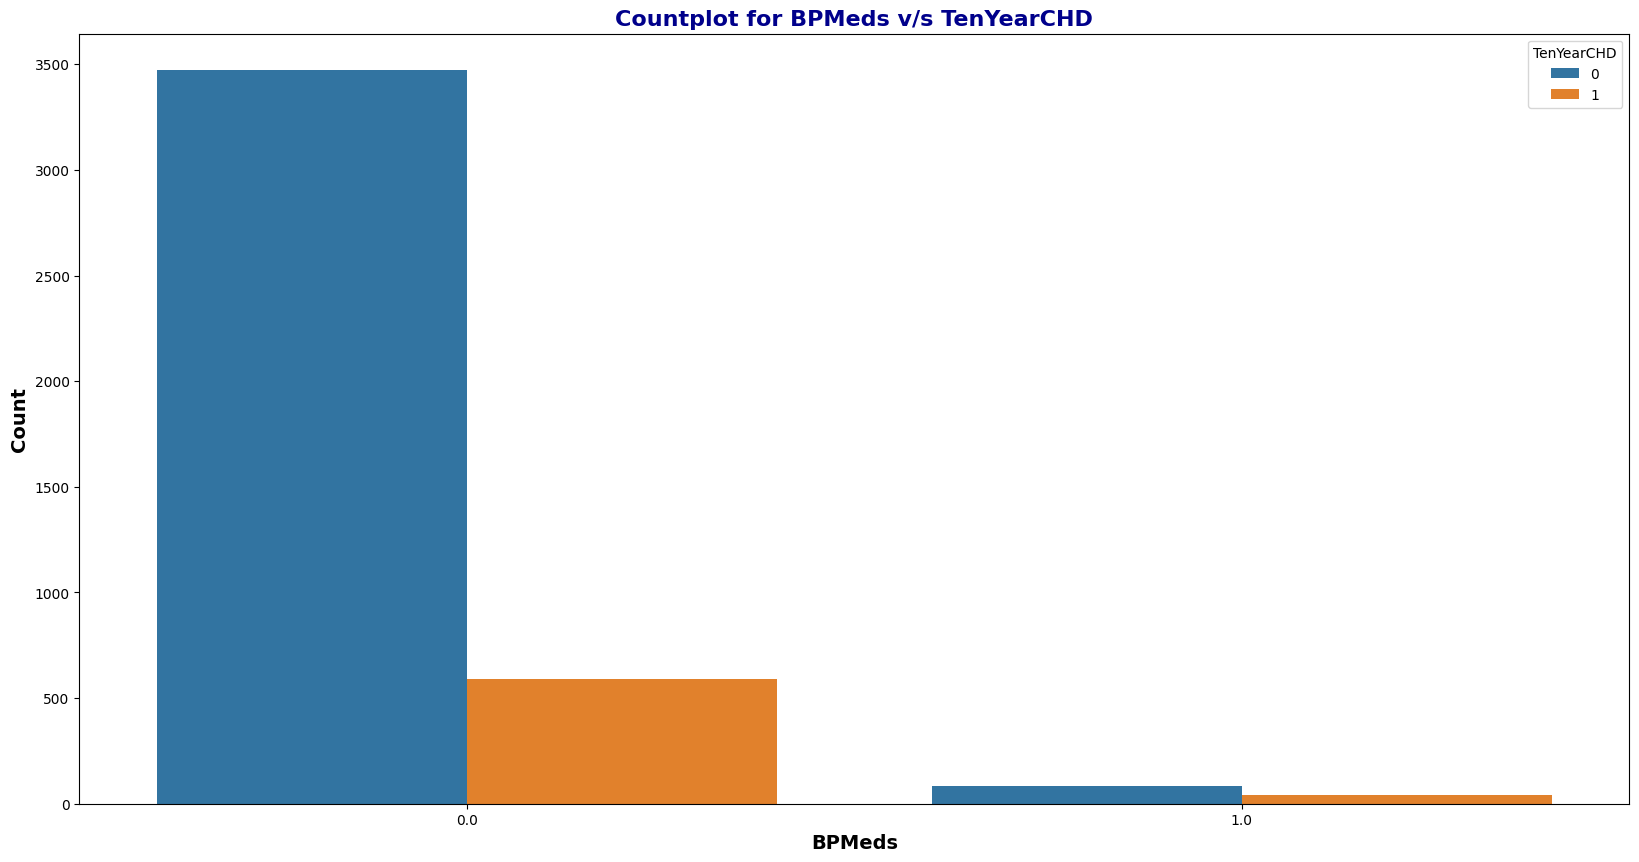

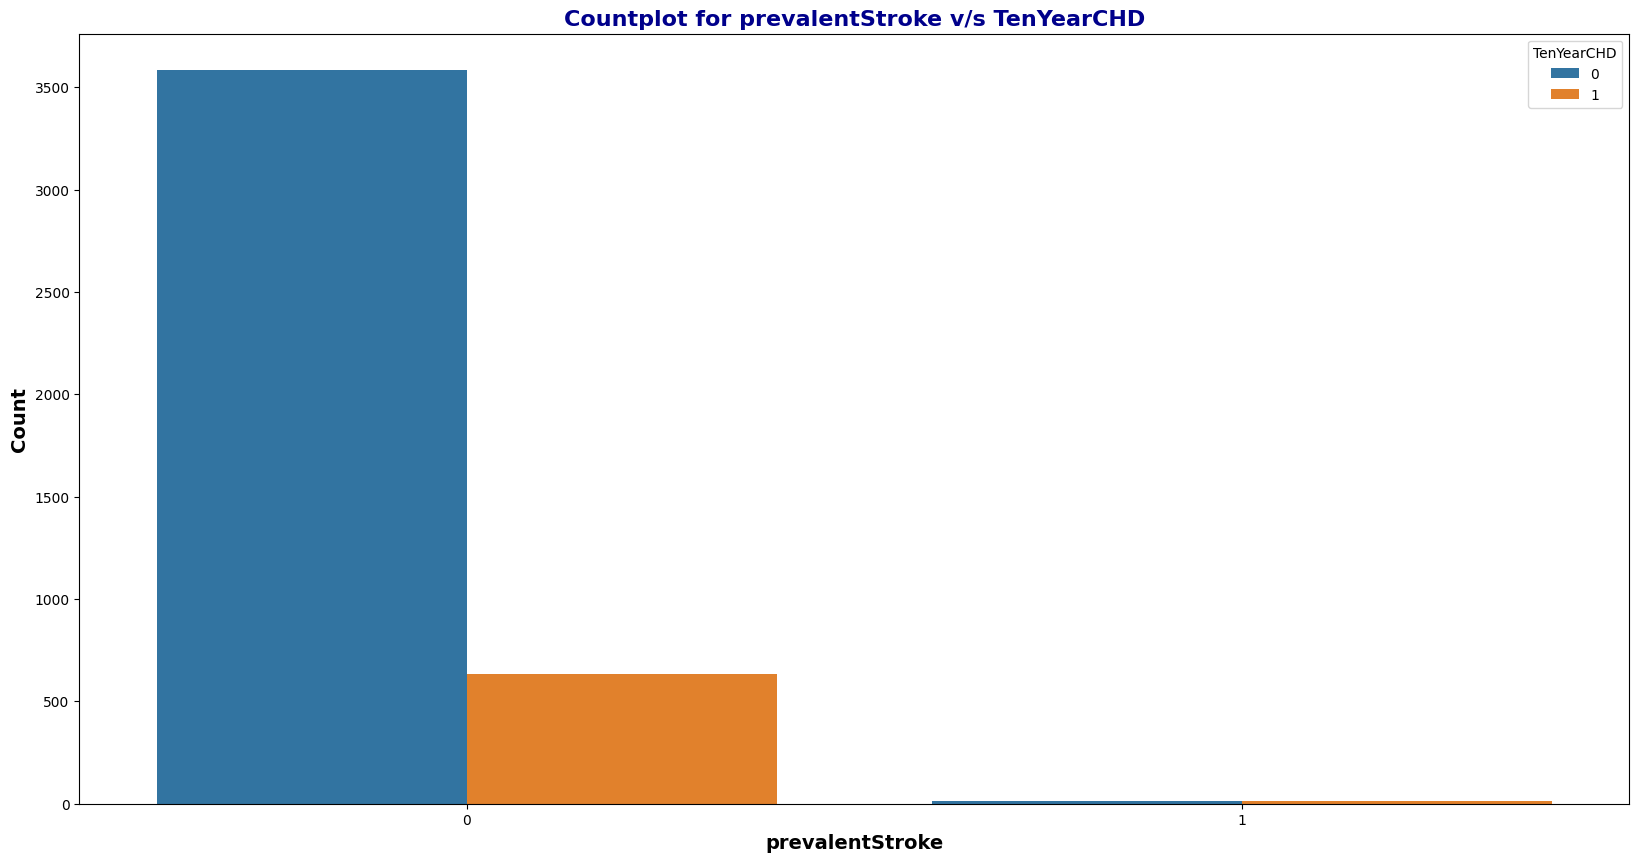

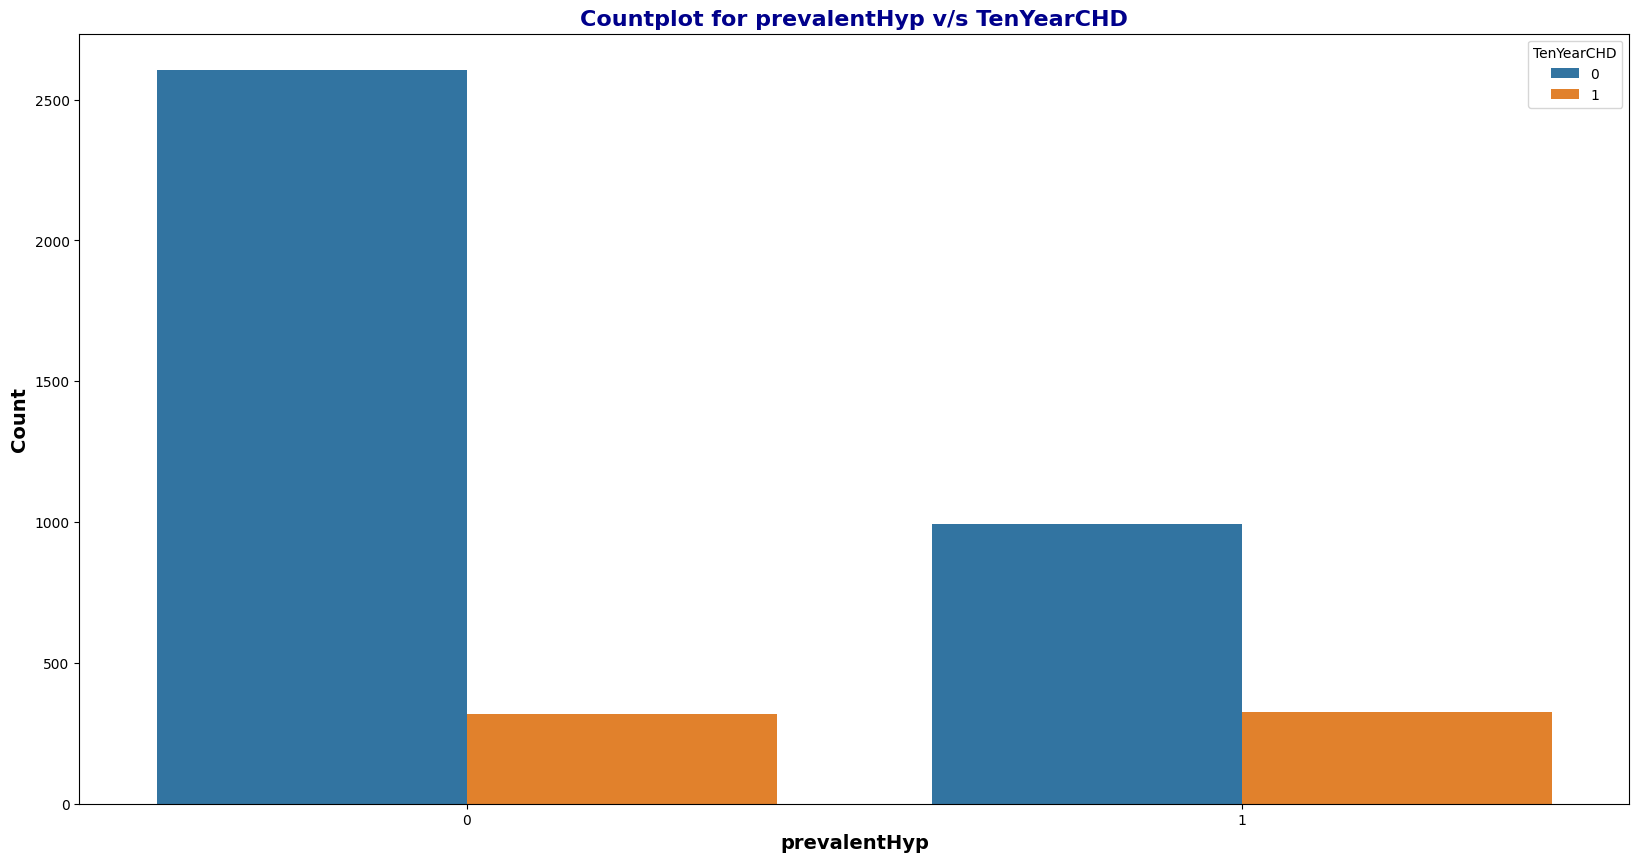

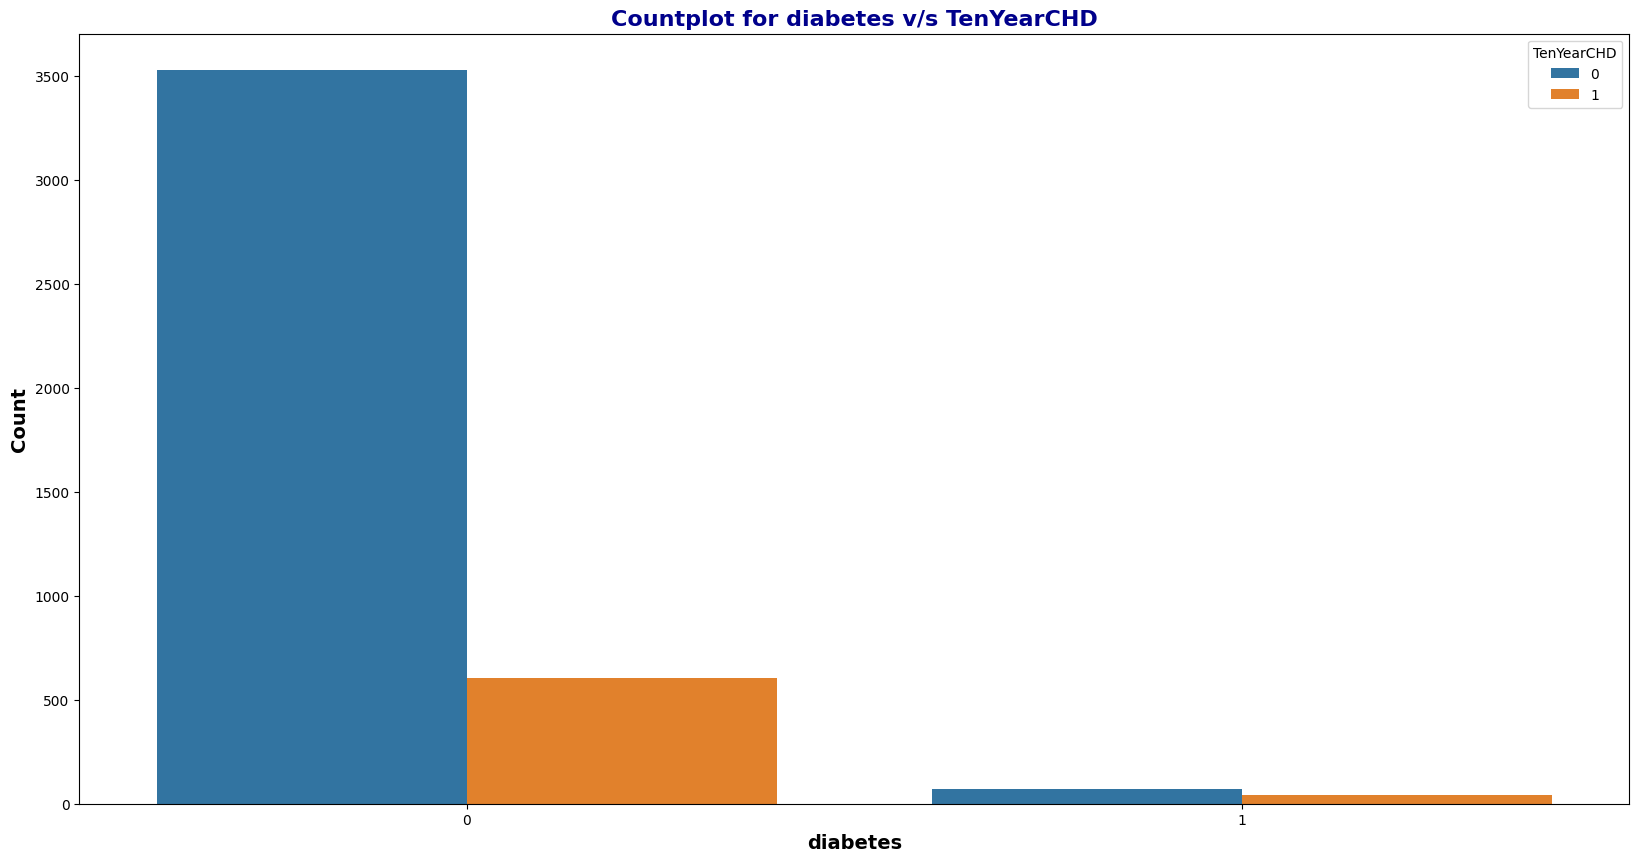

In [95]:
# Bivariate Analysis - Countplot for features vs TenYearCHD
cat_features = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

for col in cat_features:
    plt.figure(figsize = (20,10))
    sns.countplot(data = df, x = col, hue = 'TenYearCHD')
    plt.title(f'Countplot for {col} v/s TenYearCHD', fontsize = 16, fontweight = 'bold', color = 'darkblue')
    plt.xlabel(col, fontsize = 14, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 14, fontweight = 'bold')
    plt.show()

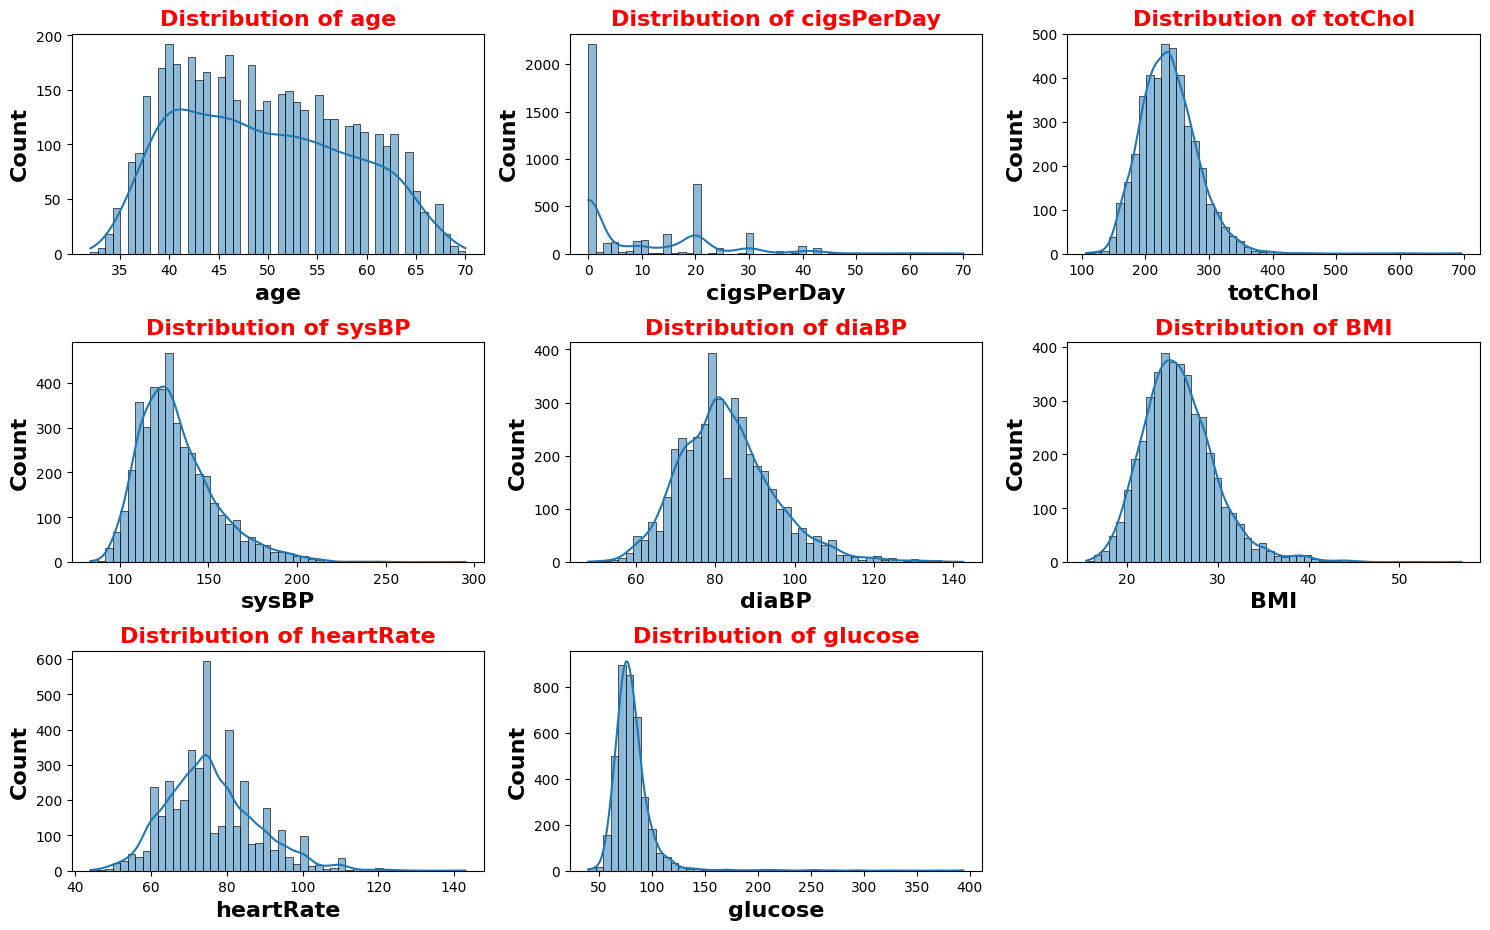

In [96]:
# Histplot for numerical features
num_features = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

plt.figure(figsize = (15, 12))
for i, col in enumerate(num_features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data = df, x = col, kde = True, bins = 50)
    plt.title(f'Distribution of {col}', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

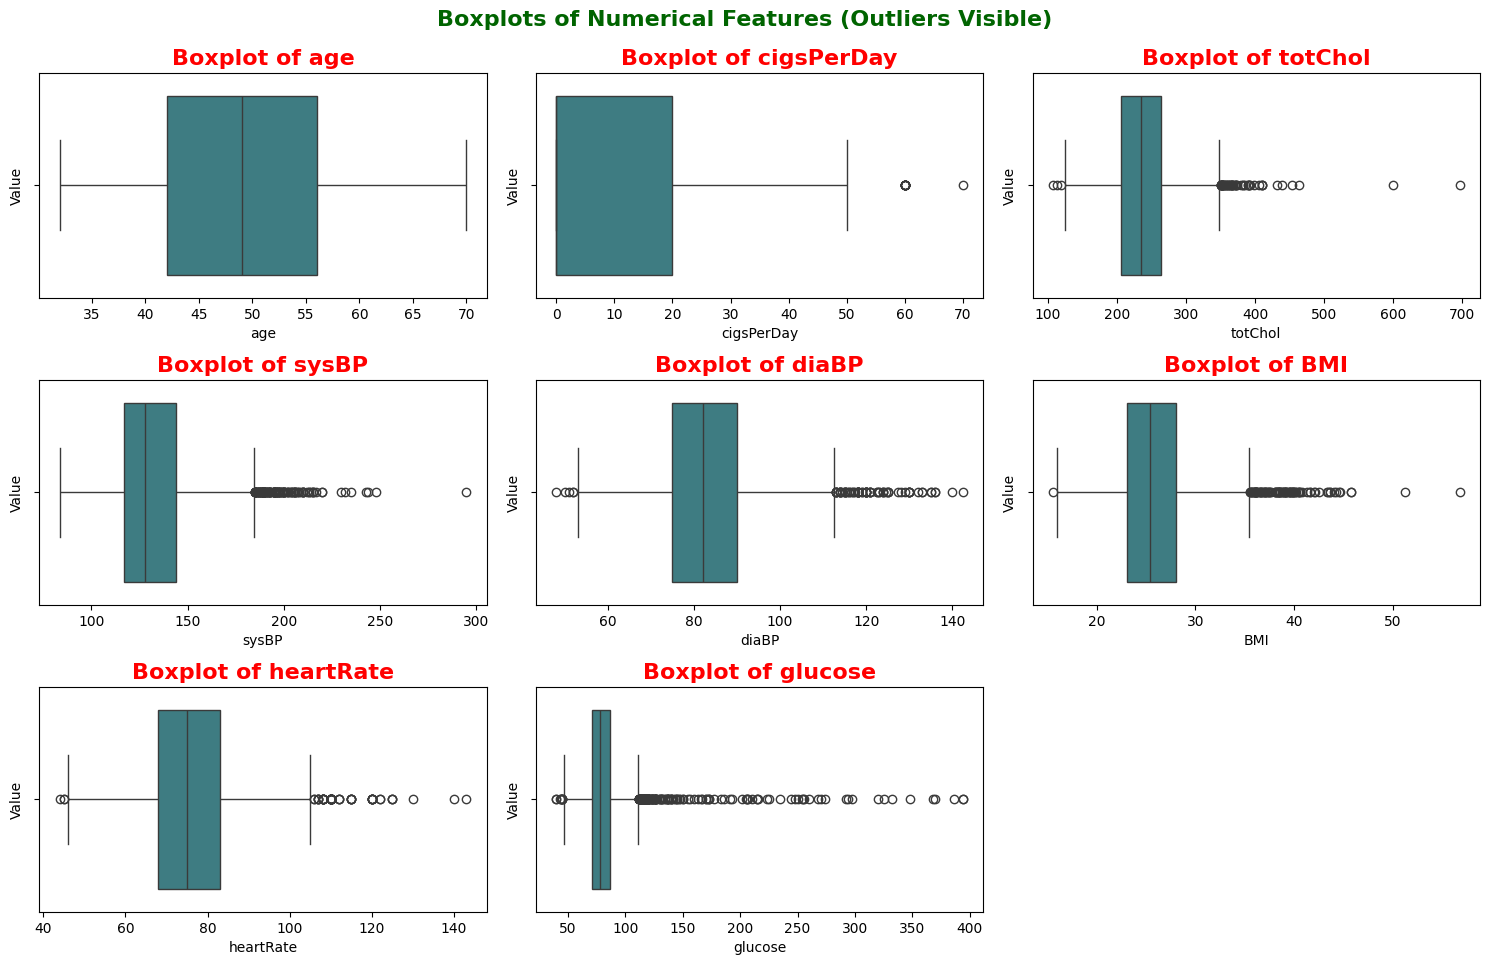

In [98]:
# Boxplot for numerical features
num_features = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

plt.figure(figsize = (15, 12))
for i, col in enumerate(num_features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data = df, x = col, orient = 'h', palette = 'crest')
    plt.title(f'Boxplot of {col}', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col)
    plt.ylabel('Value')
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features (Outliers Visible)', fontsize = 16, fontweight = 'bold', color = 'darkgreen', y = 1.02)
plt.show()

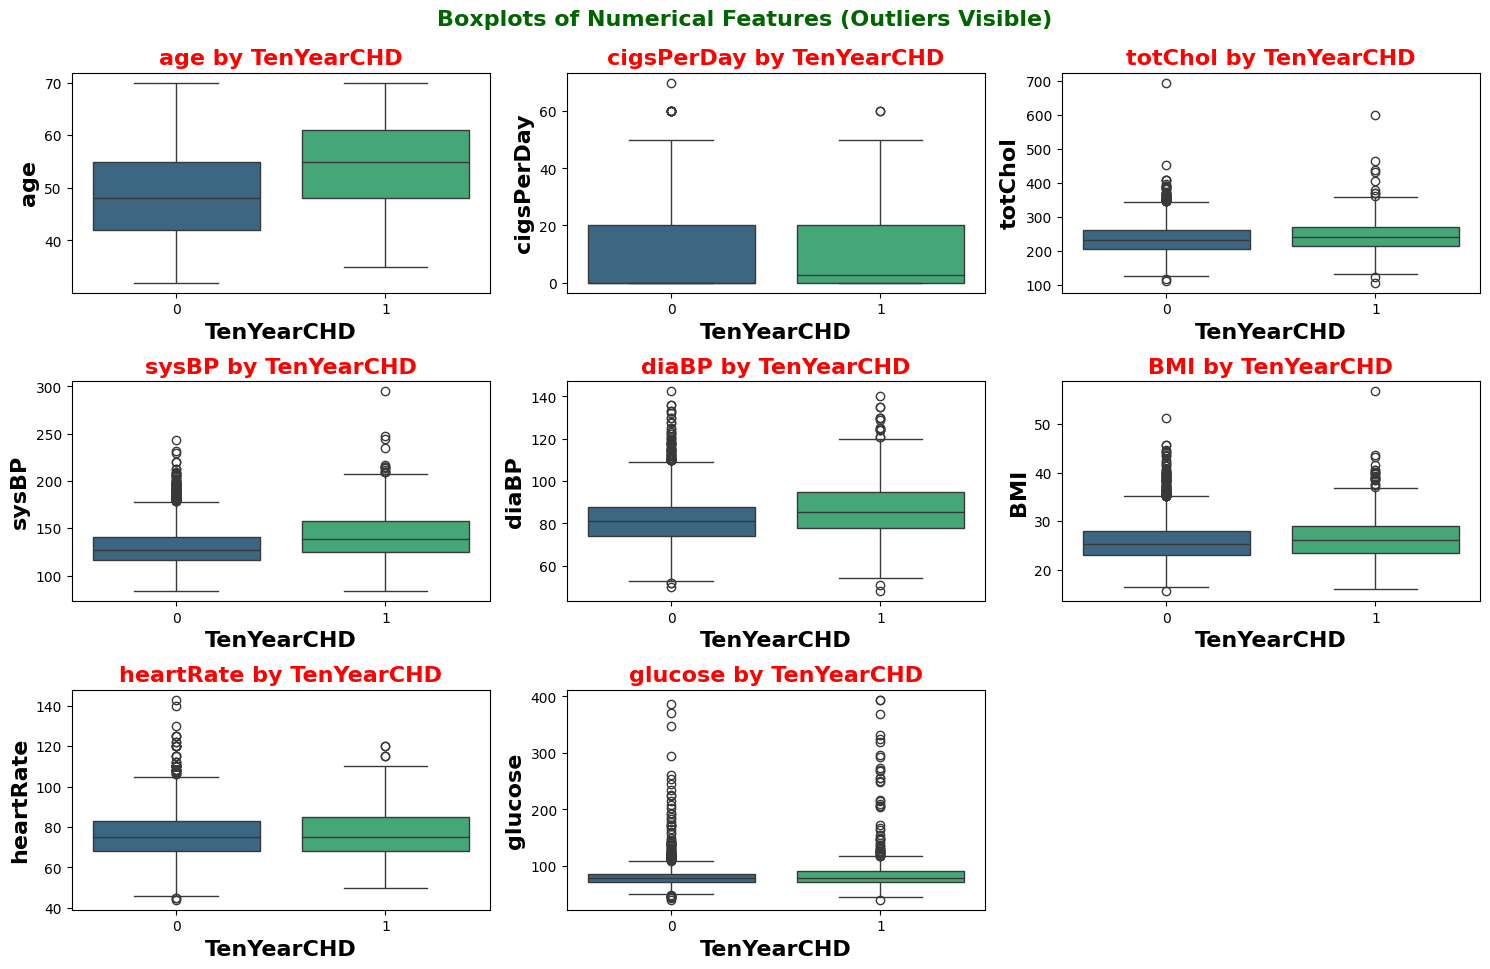

In [99]:
# Boxplots for numerical features v/s TenYearCHD
num_features = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

plt.figure(figsize = (15, 12))
for i, col in enumerate(num_features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data = df, x = 'TenYearCHD', y = col, palette = 'viridis')
    plt.title(f'{col} by TenYearCHD', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel('TenYearCHD', fontsize = 16, fontweight = 'bold')
    plt.ylabel(col, fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features (Outliers Visible)', fontsize = 16, fontweight = 'bold', color = 'darkgreen', y = 1.02)
plt.show()

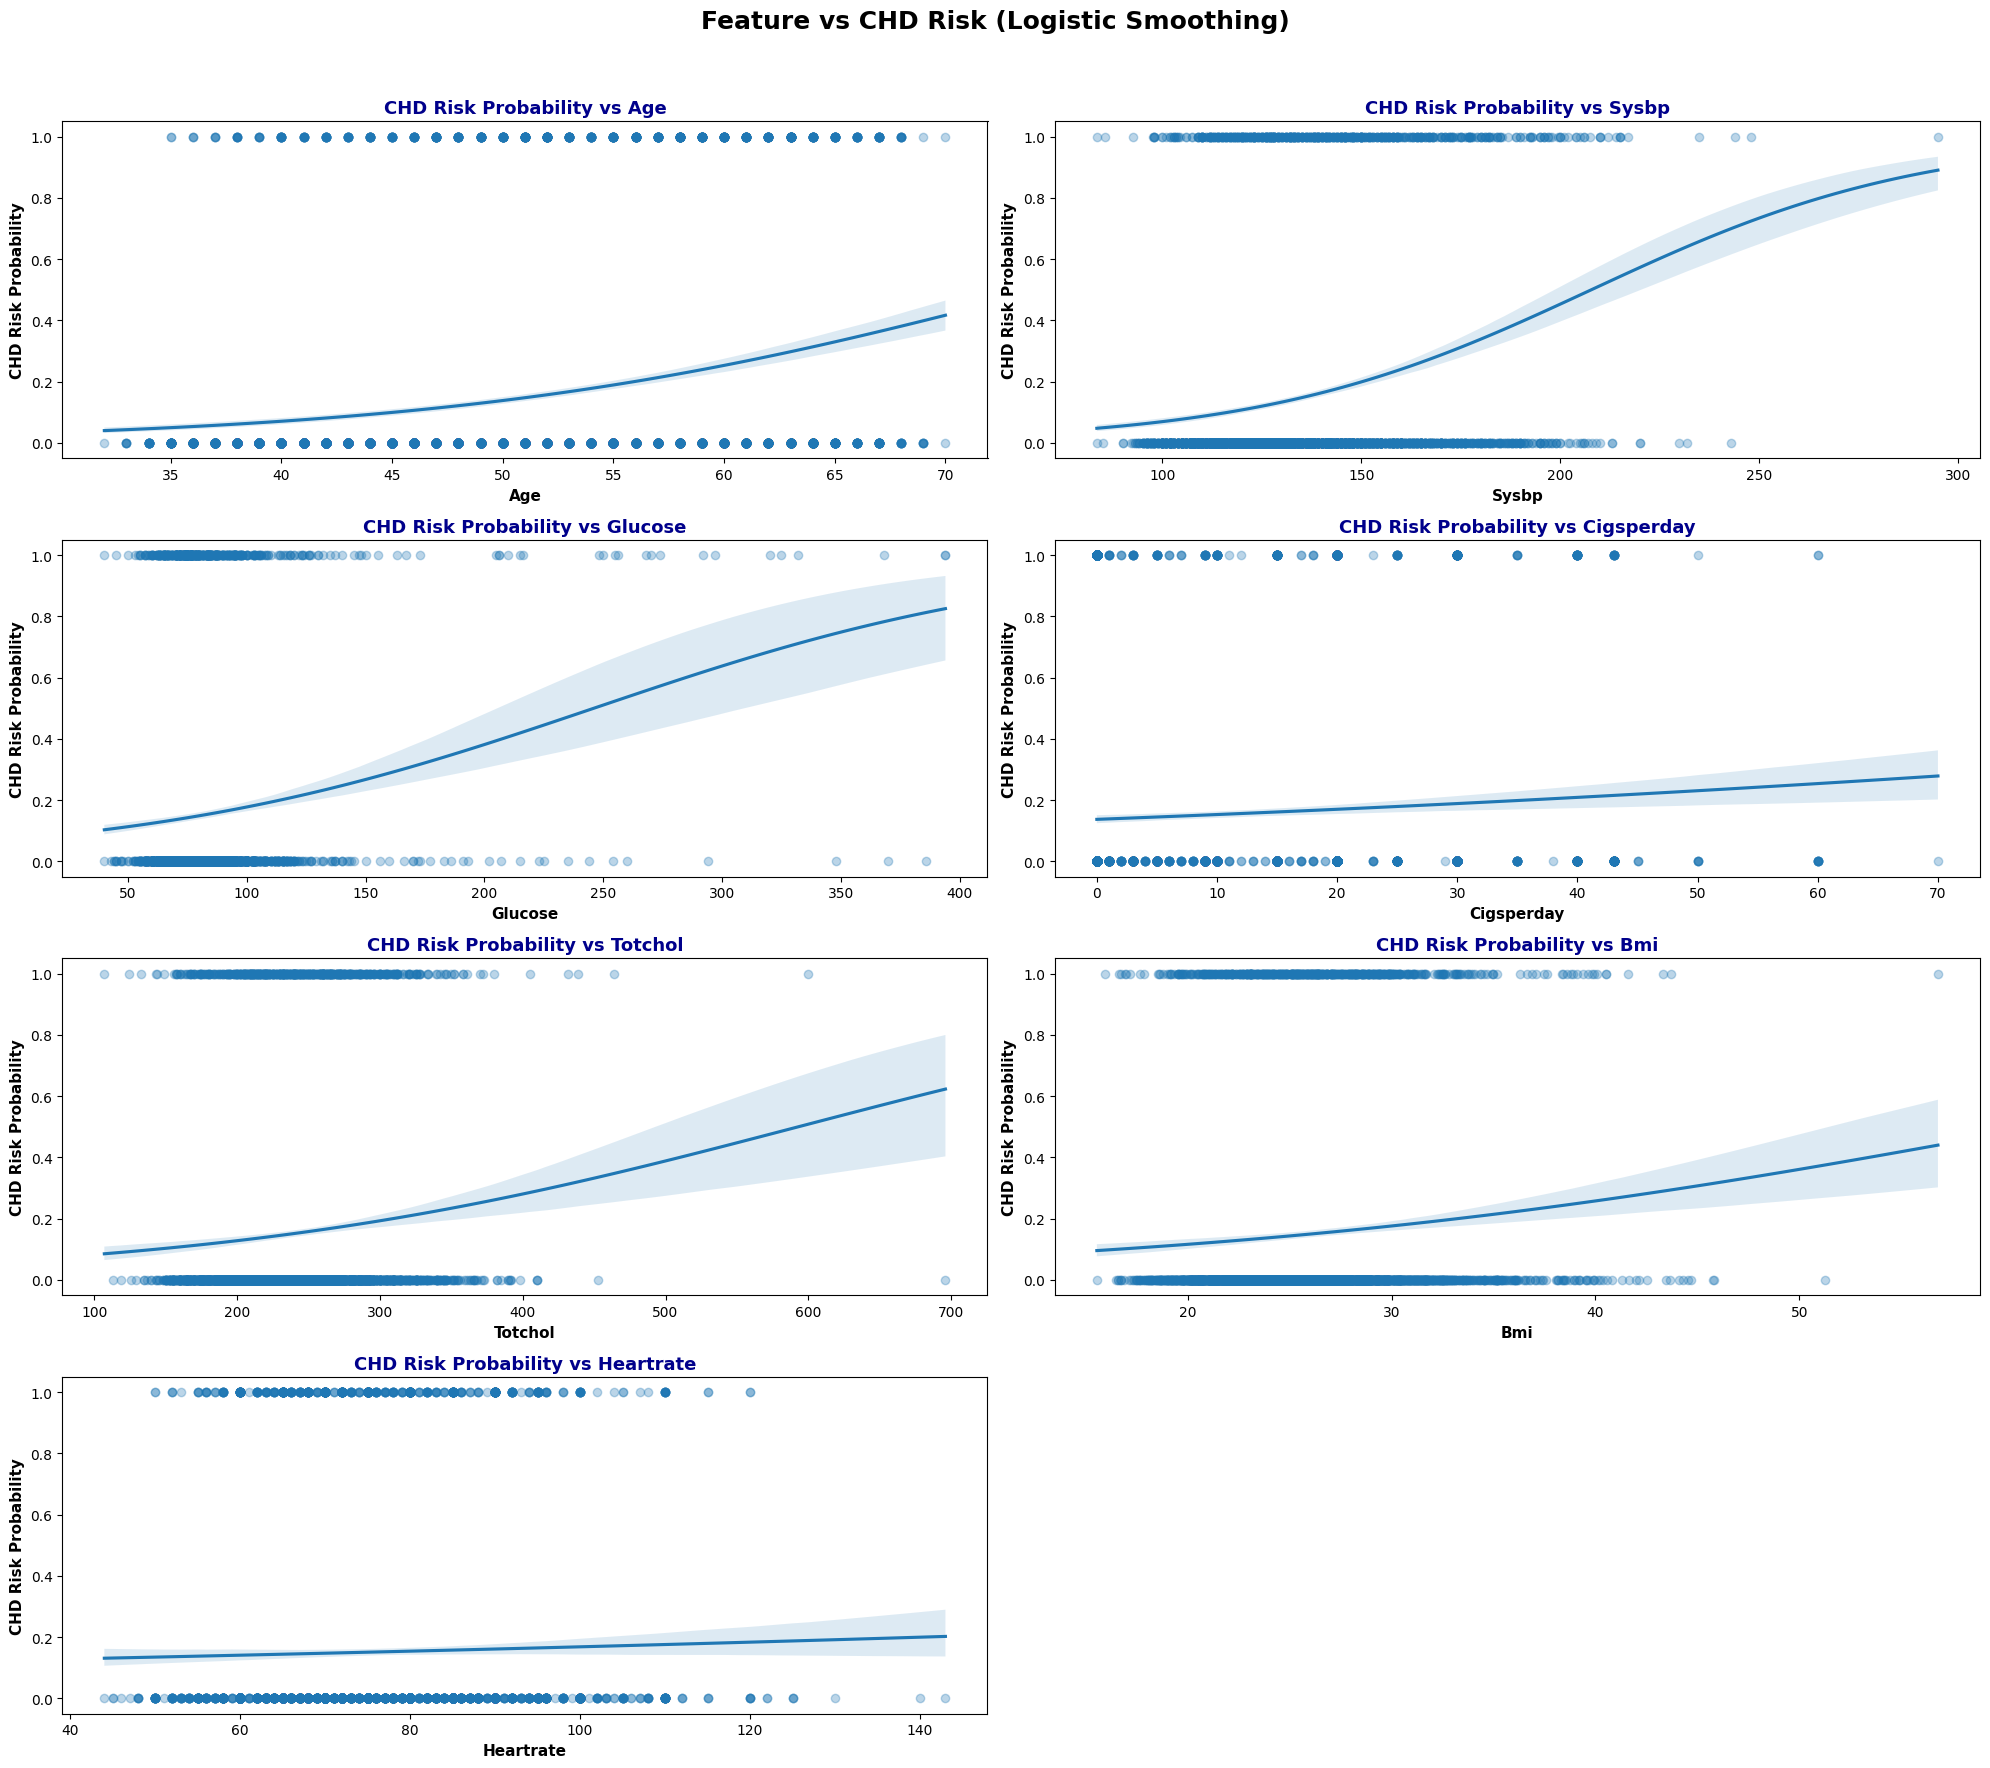

In [115]:
# Feature vs CHD Risk (with smoothing)
features = ['age', 'sysBP', 'glucose', 'cigsPerDay', 'totChol', 'BMI', 'heartRate']

# 4 rows × 2 columns grid
fig, axes = plt.subplots(4, 2, figsize = (20, 18))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.regplot(x = feature, y = 'TenYearCHD', data = df, logistic = True, scatter_kws = {'alpha':0.3}, ax = ax)
    ax.set_title(f'CHD Risk Probability vs {feature.replace("_"," ").title()}', fontsize = 13, fontweight = 'bold', color = 'darkblue')
    ax.set_xlabel(feature.replace('_',' ').title(), fontsize = 12, fontweight = 'bold')
    ax.set_ylabel('CHD Risk Probability', fontsize = 12, fontweight = 'bold')

# Hide unused subplot
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle('Feature vs CHD Risk (Logistic Smoothing)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

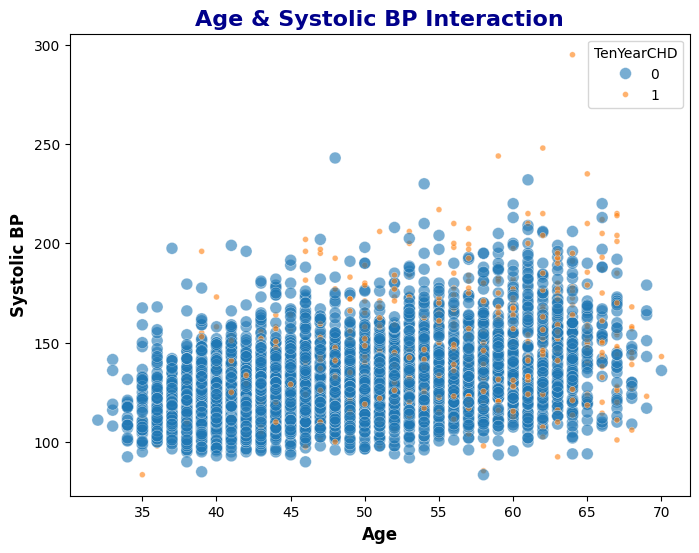

In [116]:
# Age + BP + CHD (bubble plot)
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'age', y = 'sysBP', size = 'TenYearCHD', hue = 'TenYearCHD', data = df, alpha = 0.6)
plt.title("Age & Systolic BP Interaction", fontsize = 16, fontweight = 'bold', color = 'darkblue')
plt.xlabel("Age", fontsize = 12, fontweight = 'bold')
plt.ylabel("Systolic BP", fontsize = 12, fontweight = 'bold')
plt.show()

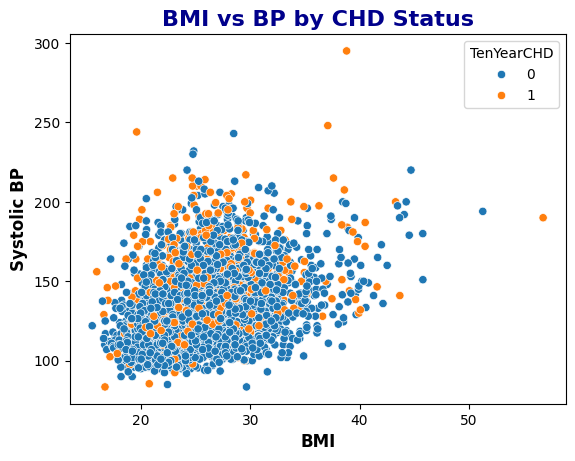

In [117]:
# BMI vs BP colored by CHD
sns.scatterplot(x = 'BMI', y = 'sysBP', hue = 'TenYearCHD', data = df)
plt.title("BMI vs BP by CHD Status", fontsize = 16, fontweight = 'bold', color = 'darkblue')
plt.xlabel("BMI", fontsize = 12, fontweight = 'bold')
plt.ylabel("Systolic BP", fontsize = 12, fontweight = 'bold')
plt.show()

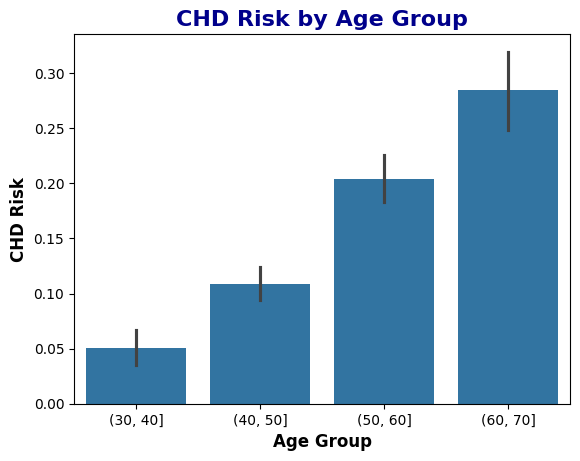

In [118]:
# CHD risk by Age Groups
df['age_group'] = pd.cut(df['age'], bins = [30,40,50,60,70])
sns.barplot(x = 'age_group', y = 'TenYearCHD', data = df)
plt.title("CHD Risk by Age Group", fontsize = 16, fontweight = 'bold', color = 'darkblue')
plt.xlabel("Age Group", fontsize = 12, fontweight = 'bold')
plt.ylabel("CHD Risk", fontsize = 12, fontweight = 'bold')
plt.show()

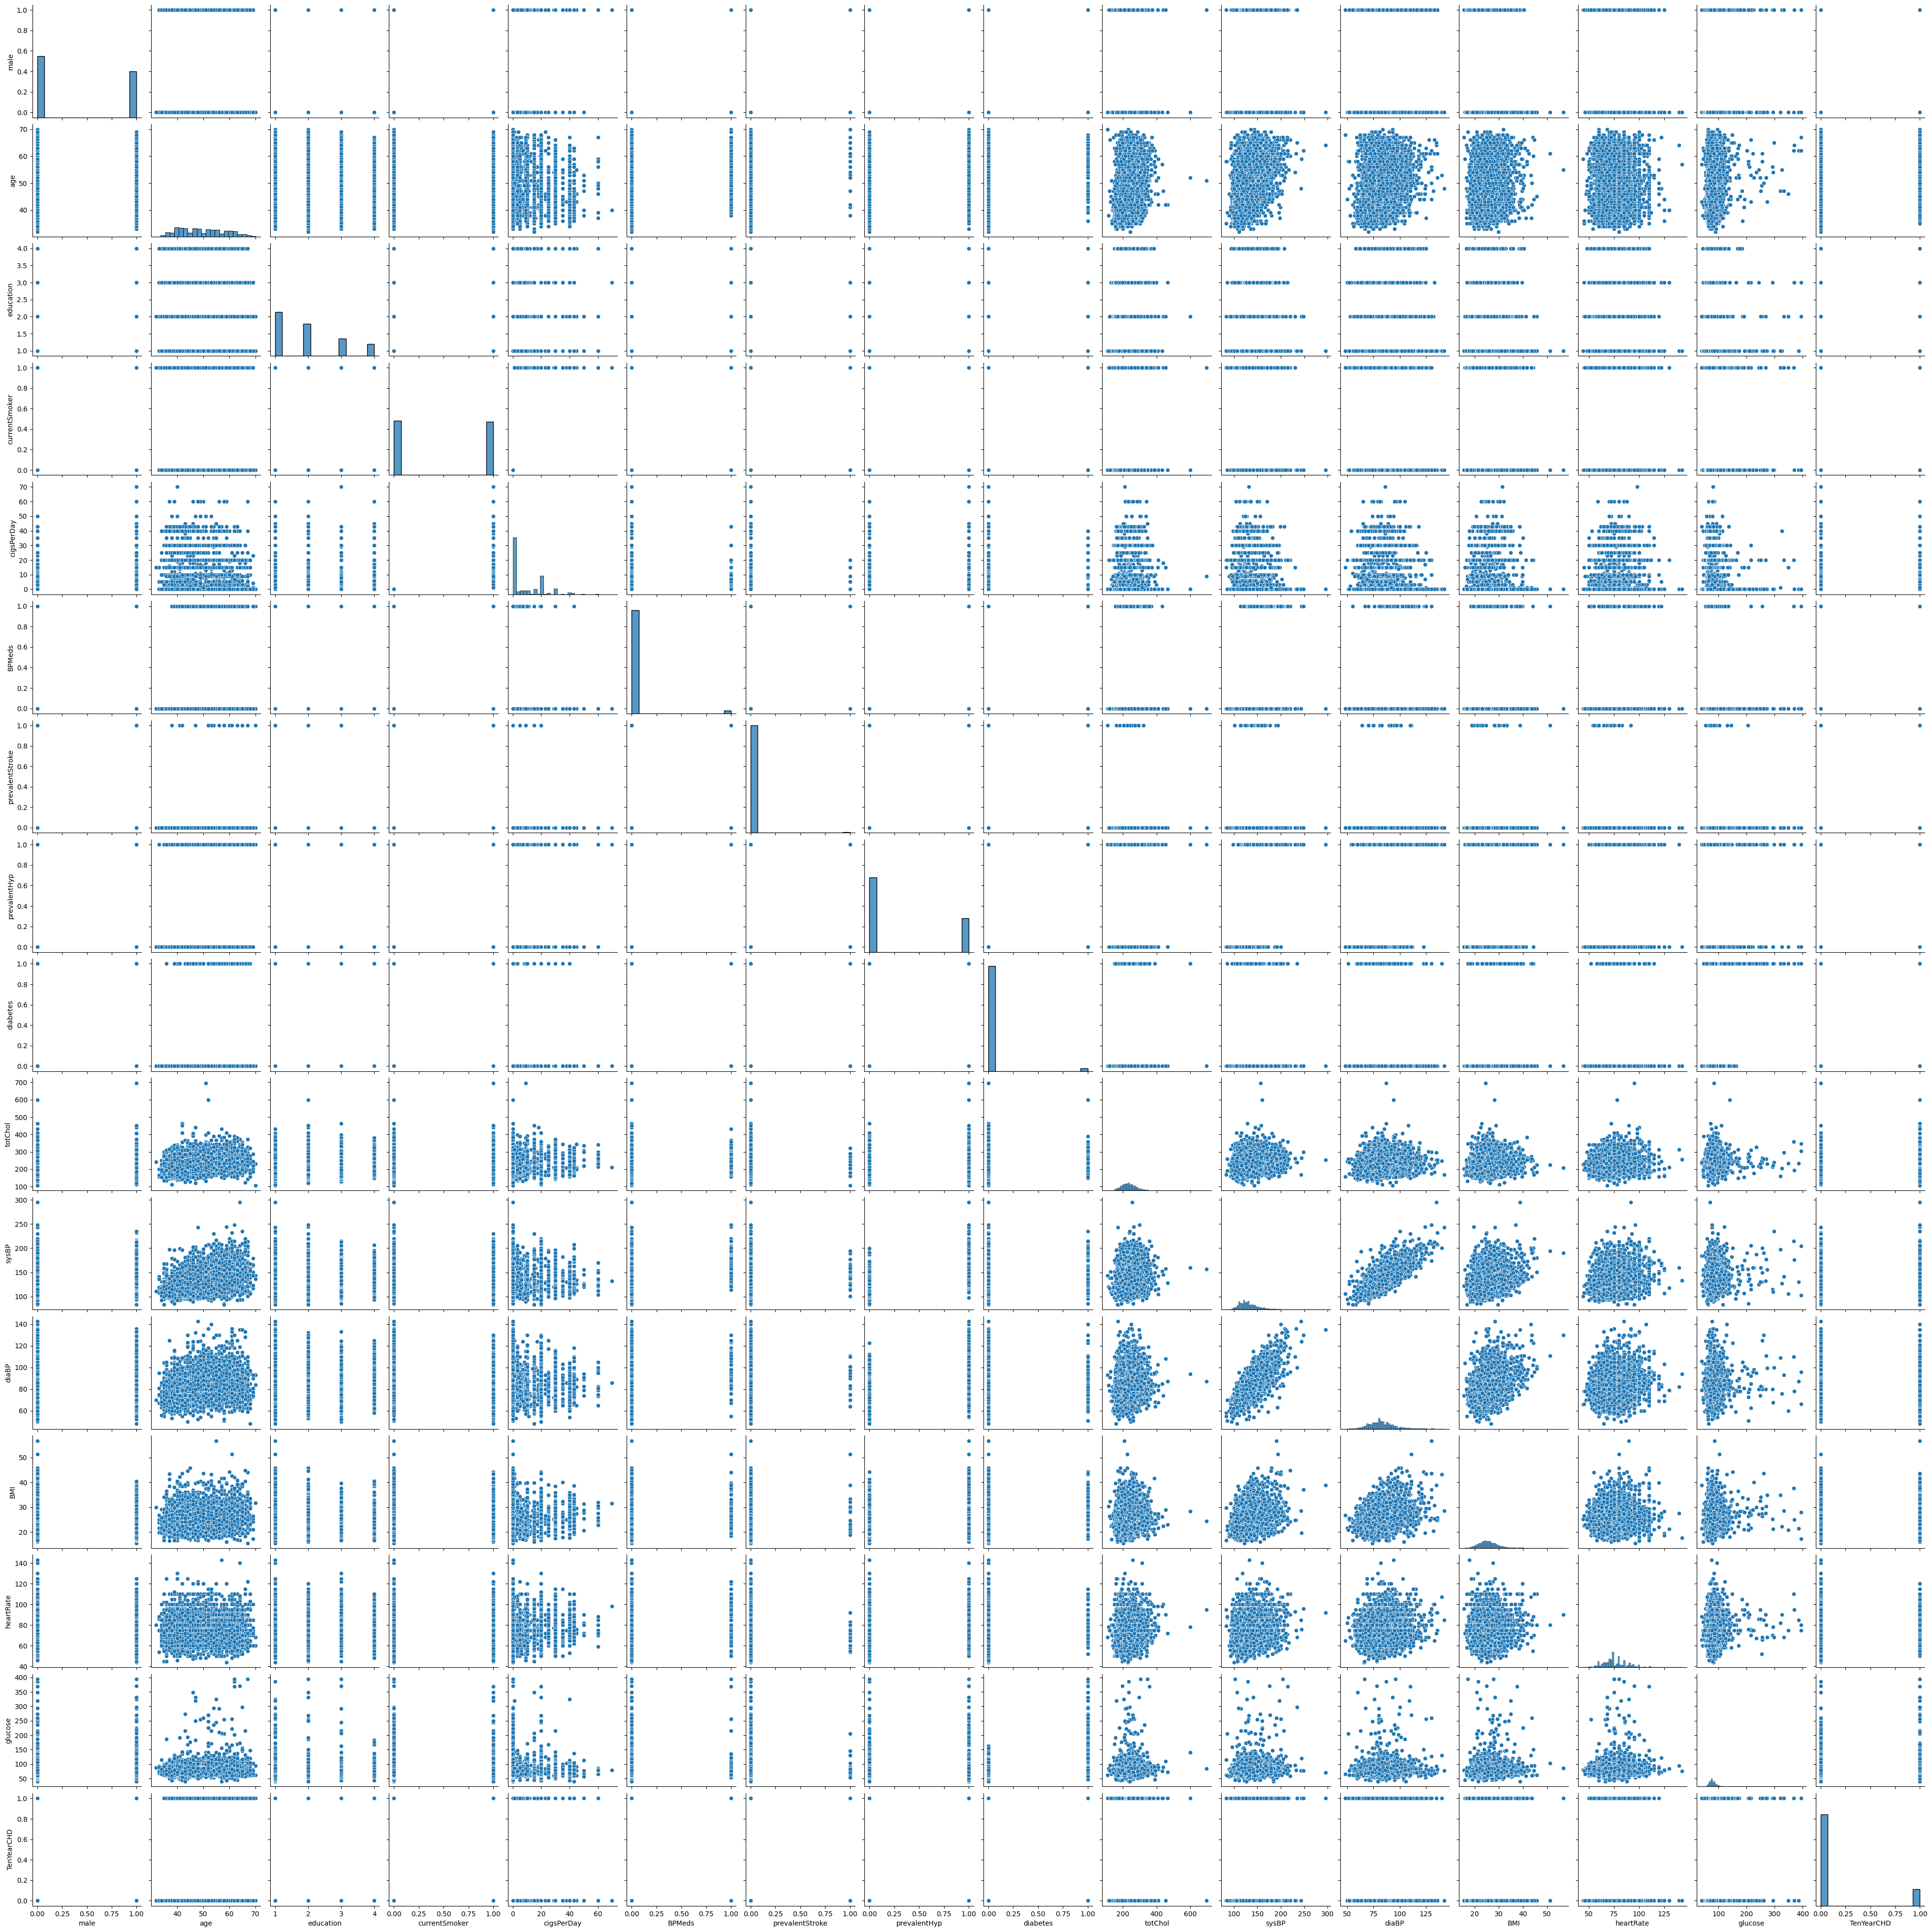

In [103]:
# Pairplot
sns.pairplot(df, palette = 'viridis')
plt.show()

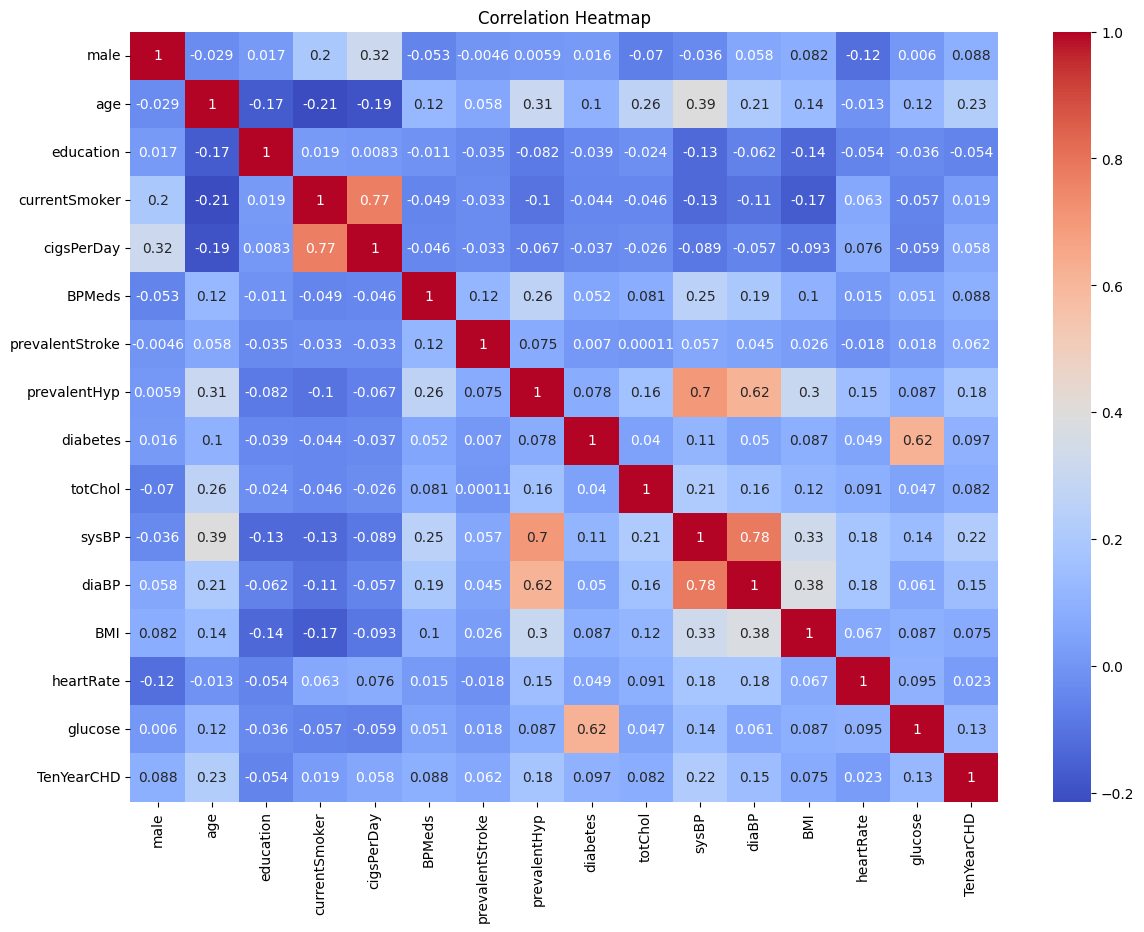

In [83]:
# Heatmap for correlation
plt.figure(figsize = (14,10))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Attempt 1: Building models after dropping missing values in the dataset:**

In [23]:
# Drop the missing values
df = df.dropna()

In [24]:
df.shape

(3658, 16)

In [25]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
male,0,0.0
age,0,0.0
education,0,0.0
currentSmoker,0,0.0
cigsPerDay,0,0.0
BPMeds,0,0.0
prevalentStroke,0,0.0
prevalentHyp,0,0.0
diabetes,0,0.0
totChol,0,0.0


In [26]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

# **The dataset is clean with no duplicates and no missing values!**

In [27]:
df["TenYearCHD"].value_counts()

,count
TenYearCHD,
0,3101
1,557


The Framingham CHD prediction dataset is clearly an imbalanced dataset:

Developed CHD (positive class / minority): 557

Did NOT develop CHD (negative class / majority): 3,101

Total samples = 557 + 3,101 = 3,658

If you train a model that ignores imbalance, it can achieve ~85% accuracy just by always predicting "No CHD". But it will have very poor detection of people who actually will develop CHD (very low recall for the positive class). In medical prediction this is dangerous — missing people who are actually at risk is much worse than some false alarms

In [28]:
# Drop the education feature since it is redundant
df = df.drop("education", axis = 1)

In [29]:
df["male"].value_counts()

,count
male,
0,2035
1,1623


In [30]:
df["currentSmoker"].value_counts()

,count
currentSmoker,
0,1869
1,1789


In [31]:
df["BPMeds"] = df["BPMeds"].astype("int")

In [32]:
df["BPMeds"].value_counts()

,count
BPMeds,
0,3547
1,111


In [33]:
df["prevalentStroke"].value_counts()

,count
prevalentStroke,
0,3637
1,21


In [34]:
df["prevalentHyp"].value_counts()

,count
prevalentHyp,
0,2518
1,1140


In [35]:
df["diabetes"].value_counts()

,count
diabetes,
0,3559
1,99


In [36]:
df["TenYearCHD"].value_counts()

,count
TenYearCHD,
0,3101
1,557


In [37]:
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# **ML Models:**

# **Logistic Regression:**

# **Balanced-Weighted Logistic Regression:**

Confusion Matrix:
[[419 202]
 [ 36  75]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78       621
           1       0.27      0.68      0.39       111

    accuracy                           0.67       732
   macro avg       0.60      0.68      0.58       732
weighted avg       0.82      0.67      0.72       732

Accuracy: 0.674863387978142
Precision: 0.27075812274368233
Recall: 0.6756756756756757
F1 Score: 0.3865979381443299
ROC-AUC Score: 0.7244055649852752


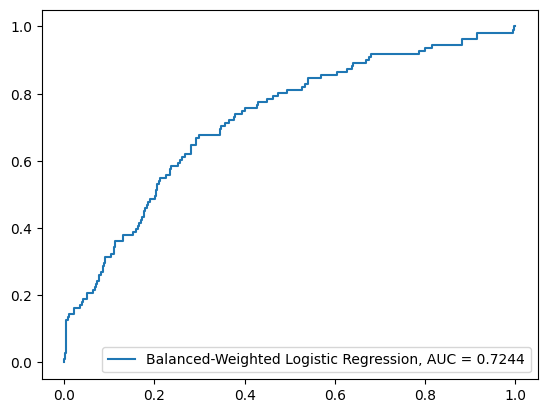

In [38]:
from sklearn.model_selection import train_test_split
X = df.drop("TenYearCHD", axis = 1)
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale only continuous features, leave binary as-is
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
lr = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "Balanced-Weighted Logistic Regression, AUC = "+str(auc))
plt.legend()

# **Logistic Regression with SMOTE:**

Confusion Matrix:
[[419 202]
 [ 36  75]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78       621
           1       0.27      0.68      0.39       111

    accuracy                           0.67       732
   macro avg       0.60      0.68      0.58       732
weighted avg       0.82      0.67      0.72       732

Accuracy: 0.674863387978142
Precision: 0.27075812274368233
Recall: 0.6756756756756757
F1 Score: 0.3865979381443299
ROC-AUC Score: 0.7205611408509958


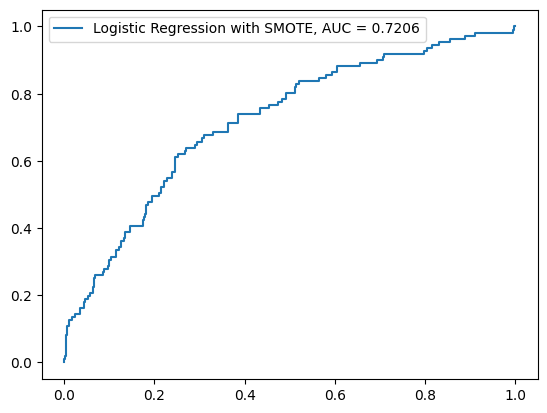

In [39]:
from sklearn.model_selection import train_test_split
X = df.drop("TenYearCHD", axis = 1)
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale only continuous features, leave binary as-is
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "Logistic Regression with SMOTE, AUC = "+str(auc))
plt.legend()

# **KNN:**

# **Distance-Weighted KNN:**

Confusion Matrix: 
[[605  16]
 [ 99  12]] 

Classification Report: 
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       621
           1       0.43      0.11      0.17       111

    accuracy                           0.84       732
   macro avg       0.64      0.54      0.54       732
weighted avg       0.79      0.84      0.80       732

Accuracy: 0.842896174863388
Precision: 0.42857142857142855
Recall: 0.10810810810810811
F1 Score: 0.17266187050359713


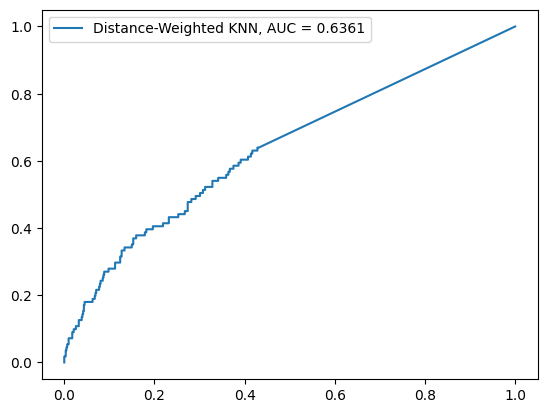

In [40]:
# from sklearn.model_selection import train_test_split
X = df.drop("TenYearCHD", axis = 1)
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale only continuous features, leave binary as-is
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
knn_classifier = KNN(n_neighbors = 5, weights = 'distance')
knn_classifier.fit(X_train, y_train)

# Predictions
y_pred = knn_classifier.predict(X_test)
y_prob = knn_classifier.predict_proba(X_test)[:,-1]

print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report: ")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "Distance-Weighted KNN, AUC = "+str(auc))
plt.legend()

##  **The optimal \(k\) is usually found where the performance curve peaks or the error rate is lowest before the performance starts to degrade.**

# **KNN with Stratified Cross-Validation:**

# Stratified cross-validation to tune hyperparameters, optimizing recall due to the clinical importance of identifying CHD cases

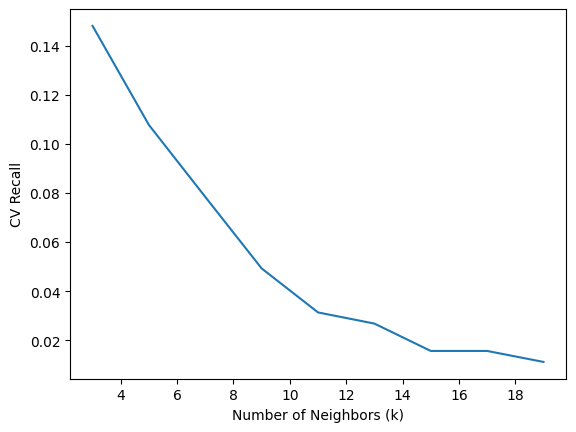

Best k: 3
Confusion Matrix: 
[[589  32]
 [ 95  16]] 

Classification Report: 
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       621
           1       0.33      0.14      0.20       111

    accuracy                           0.83       732
   macro avg       0.60      0.55      0.55       732
weighted avg       0.78      0.83      0.80       732

Accuracy: 0.8265027322404371
Precision: 0.3333333333333333
Recall: 0.14414414414414414
F1 Score: 0.20125786163522014


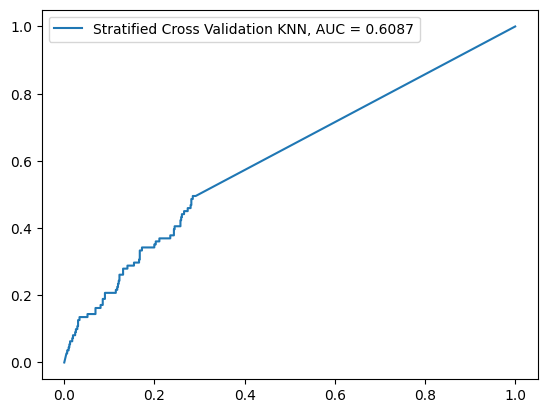

In [41]:
from sklearn.model_selection import train_test_split
X = df.drop("TenYearCHD", axis = 1)
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale only continuous features, leave binary as-is
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

k_values = range(3, 21, 2)
recall_scores = []

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

for k in k_values:
  knn = KNN(n_neighbors = k, weights = 'distance')
  score = cross_val_score(knn, X_train, y_train, cv = cv, scoring = 'recall')
  recall_scores.append(score.mean())

plt.plot(k_values, recall_scores)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("CV Recall")
plt.show()

# Select best k value
best_k = k_values[np.argmax(recall_scores)]
print("Best k:", best_k)

# Train model for best k value
knn_classifier_final = KNN(n_neighbors = best_k, weights = 'distance')
knn_classifier_final.fit(X_train, y_train)

# Predictions
y_pred = knn_classifier_final.predict(X_test)
y_prob = knn_classifier_final.predict_proba(X_test)[:,-1]

print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report: ")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "Stratified Cross Validation KNN, AUC = "+str(auc))
plt.legend()

# **KNN with SMOTE:**

Confusion Matrix:
[[427 194]
 [ 54  57]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.69      0.77       621
           1       0.23      0.51      0.31       111

    accuracy                           0.66       732
   macro avg       0.56      0.60      0.54       732
weighted avg       0.79      0.66      0.71       732

Accuracy: 0.6612021857923497
Precision: 0.22709163346613545
Recall: 0.5135135135135135
F1 Score: 0.3149171270718232
ROC-AUC Score: 0.6383557470513992


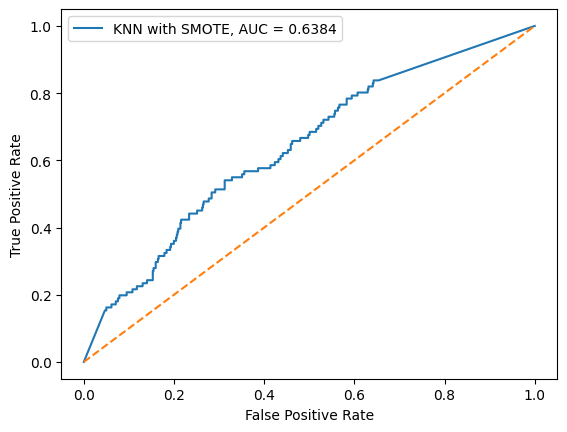

In [42]:
# Train–Test Split
from sklearn.model_selection import train_test_split
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scaling (Train only)
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])


# Apply SMOTE (Train only)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# Train KNN Model
from sklearn.neighbors import KNeighborsClassifier as KNN
knn_smote = KNN(n_neighbors=7,weights='distance')
knn_smote.fit(X_train_smote, y_train_smote)


# Predictions
y_pred = knn_smote.predict(X_test)
y_prob = knn_smote.predict_proba(X_test)[:, 1]

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ROC Curve
from sklearn import metrics
import matplotlib.pyplot as plt

fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)

plt.plot(fpr, tpr, label="KNN with SMOTE, AUC = " + str(auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# **XGBoost Classifier:**

Confusion Matrix: 
[[475 146]
 [ 65  46]] 

Classification Report: 
              precision    recall  f1-score   support

           0       0.88      0.76      0.82       621
           1       0.24      0.41      0.30       111

    accuracy                           0.71       732
   macro avg       0.56      0.59      0.56       732
weighted avg       0.78      0.71      0.74       732

Accuracy score:0.7117486338797814
Precision score:0.23958333333333334
Recall score:0.4144144144144144
F1 score:0.30363036303630364
XGBoost ROC-AUC Score: 0.6583104843974409


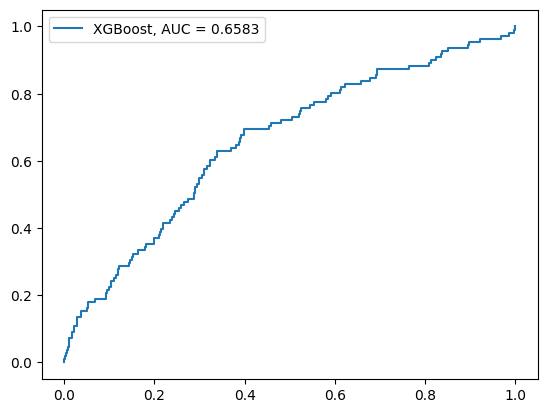

In [43]:
# Train–Test Split
from sklearn.model_selection import train_test_split
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Train model
from xgboost import XGBClassifier
xgb_classifier = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 5, objective = 'binary:logistic',
                               scale_pos_weight = 5.57, eval_metric = 'auc', random_state = 42)
xgb_classifier.fit(X_train, y_train)

# n_estimators = Number of trees to build
# learning_rate = Step size shrinkage (prevent overfitting)
# max_depth= Maximum tree depth
# objective='binary:logistic' = Output probabilities for binary labels

# Predict
y_pred = xgb_classifier.predict(X_test)
y_prob = xgb_classifier.predict_proba(X_test)[:,-1]

from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred), "\n")
print("Classification Report: ")
print(classification_report(y_test, y_pred))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy score:" +str(accuracy_score(y_test,y_pred)))
print("Precision score:" +str(precision_score(y_test,y_pred)))
print("Recall score:" +str(recall_score(y_test,y_pred)))
print("F1 score:" +str(f1_score(y_test,y_pred)))

# ROC-AUC Curve (Receiver operating characteristic - Area under curve)
from sklearn.metrics import roc_auc_score
xgb_roc_score = roc_auc_score(y_test, y_prob)
print("XGBoost ROC-AUC Score: " +str(xgb_roc_score))

from sklearn import metrics
xgb_probabilities = xgb_classifier.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "XGBoost, AUC = "+str(auc))
plt.legend()

# **Attempt 2: Building models after missing values imputation in the dataset:**

In [44]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [45]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df1 = pd.read_csv("/content/drive/MyDrive/Datasets/framingham.csv")
df1.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [46]:
# Print the last 5 rows
df1.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [47]:
# Print the shape of the dataframe
df1.shape

(4240, 16)

In [48]:
# Statistical summary of the numerical columns of the dataframe
df1.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [49]:
# Data type of the attributes of the dataframe
df1.dtypes

,0
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64


In [50]:
# Info on the dataframe
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [51]:
df1.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [52]:
df1.keys()

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [53]:
df1.nunique()

,0
male,2
age,39
education,4
currentSmoker,2
cigsPerDay,33
BPMeds,2
prevalentStroke,2
prevalentHyp,2
diabetes,2
totChol,248


In [54]:
# Check for duplicate values
df1.duplicated().sum()

np.int64(0)

In [55]:
# Check for missing values and their percentage
missing_values = df1.isnull().sum()
missing_percentage = (df1.isnull().sum() / len(df1)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
male,0,0.000000
age,0,0.000000
education,105,2.476415
currentSmoker,0,0.000000
cigsPerDay,29,0.683962
BPMeds,53,1.250000
prevalentStroke,0,0.000000
prevalentHyp,0,0.000000
diabetes,0,0.000000
totChol,50,1.179245


In [56]:
# Drop the education feature since it is redundant
df1 = df1.drop("education", axis = 1)

In [57]:
# Imputing the following features to handle the missing values. Continuous variables are imputed with median and binary feature with mode.

df1['cigsPerDay'] = df1['cigsPerDay'].fillna(df1['cigsPerDay'].median())
df1['BPMeds'] = df1['BPMeds'].fillna(df1['BPMeds'].mode()[0])
df1['totChol'] = df1['totChol'].fillna(df1['totChol'].median())
df1['BMI'] = df1['BMI'].fillna(df1['BMI'].median())
df1['heartRate'] = df1['heartRate'].fillna(df1['heartRate'].median())
df1['glucose'] = df1['glucose'].fillna(df1['glucose'].median())

In [58]:
# Check for missing values and their percentage
missing_values = df1.isnull().sum()
missing_percentage = (df1.isnull().sum() / len(df1)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
male,0,0.0
age,0,0.0
currentSmoker,0,0.0
cigsPerDay,0,0.0
BPMeds,0,0.0
prevalentStroke,0,0.0
prevalentHyp,0,0.0
diabetes,0,0.0
totChol,0,0.0
sysBP,0,0.0


In [59]:
df1.shape

(4240, 15)

In [60]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   currentSmoker    4240 non-null   int64  
 3   cigsPerDay       4240 non-null   float64
 4   BPMeds           4240 non-null   float64
 5   prevalentStroke  4240 non-null   int64  
 6   prevalentHyp     4240 non-null   int64  
 7   diabetes         4240 non-null   int64  
 8   totChol          4240 non-null   float64
 9   sysBP            4240 non-null   float64
 10  diaBP            4240 non-null   float64
 11  BMI              4240 non-null   float64
 12  heartRate        4240 non-null   float64
 13  glucose          4240 non-null   float64
 14  TenYearCHD       4240 non-null   int64  
dtypes: float64(8), int64(7)
memory usage: 497.0 KB


# **Logistic Regression:**

# **Balanced-Weighted Logistic Regression:**

Confusion Matrix:
[[493 226]
 [ 52  77]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.69      0.78       719
           1       0.25      0.60      0.36       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.57       848
weighted avg       0.81      0.67      0.72       848

Accuracy: 0.6721698113207547
Precision: 0.25412541254125415
Recall: 0.5968992248062015
F1 Score: 0.35648148148148145
ROC-AUC Score: 0.6998415111427371


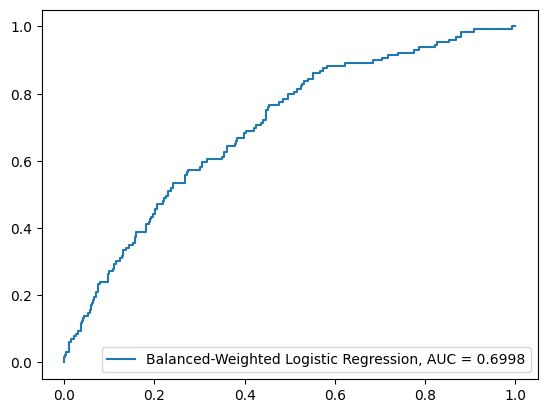

In [61]:
from sklearn.model_selection import train_test_split
X = df1.drop("TenYearCHD", axis = 1)
y = df1["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale only continuous features, leave binary as-is
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
lr = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "Balanced-Weighted Logistic Regression, AUC = "+str(auc))
plt.legend()

# **Logistic Regression with SMOTE:**

Confusion Matrix:
[[479 240]
 [ 54  75]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.67      0.77       719
           1       0.24      0.58      0.34       129

    accuracy                           0.65       848
   macro avg       0.57      0.62      0.55       848
weighted avg       0.80      0.65      0.70       848

Accuracy: 0.6533018867924528
Precision: 0.23809523809523808
Recall: 0.5813953488372093
F1 Score: 0.33783783783783783
ROC-AUC Score: 0.6970275253097001


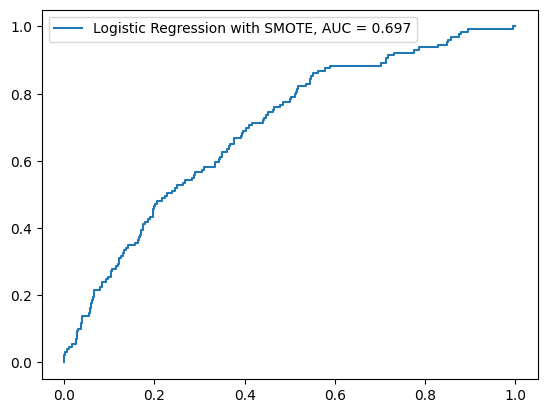

In [62]:
from sklearn.model_selection import train_test_split
X = df1.drop("TenYearCHD", axis = 1)
y = df1["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale only continuous features, leave binary as-is
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "Logistic Regression with SMOTE, AUC = "+str(auc))
plt.legend()

# **KNN:**

# **Distance-Weighted KNN:**

Confusion Matrix: 
[[697  22]
 [120   9]] 

Classification Report: 
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       719
           1       0.29      0.07      0.11       129

    accuracy                           0.83       848
   macro avg       0.57      0.52      0.51       848
weighted avg       0.77      0.83      0.79       848

Accuracy: 0.8325471698113207
Precision: 0.2903225806451613
Recall: 0.06976744186046512
F1 Score: 0.1125


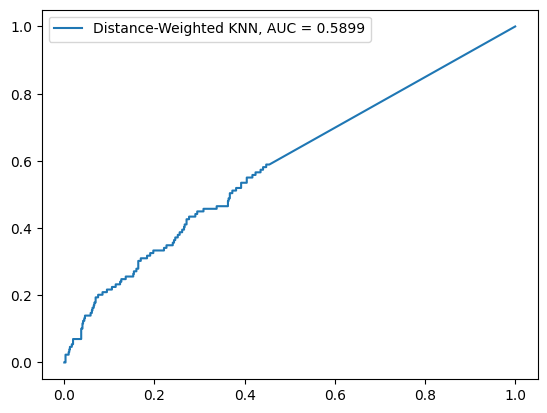

In [63]:
from sklearn.model_selection import train_test_split
X = df1.drop("TenYearCHD", axis = 1)
y = df1["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale only continuous features, leave binary as-is
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
knn_classifier = KNN(n_neighbors = 5, weights = 'distance')
knn_classifier.fit(X_train, y_train)

# Predictions
y_pred = knn_classifier.predict(X_test)
y_prob = knn_classifier.predict_proba(X_test)[:,-1]

print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report: ")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "Distance-Weighted KNN, AUC = "+str(auc))
plt.legend()

# **KNN with Stratified Cross-Validation:**

# Stratified cross-validation to tune hyperparameters, optimizing recall due to the clinical importance of identifying CHD cases

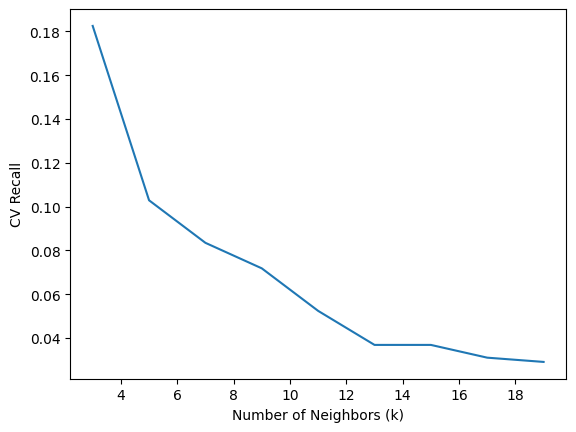

Best k: 3
Confusion Matrix: 
[[685  34]
 [117  12]] 

Classification Report: 
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       719
           1       0.26      0.09      0.14       129

    accuracy                           0.82       848
   macro avg       0.56      0.52      0.52       848
weighted avg       0.76      0.82      0.78       848

Accuracy: 0.8219339622641509
Precision: 0.2608695652173913
Recall: 0.09302325581395349
F1 Score: 0.13714285714285715


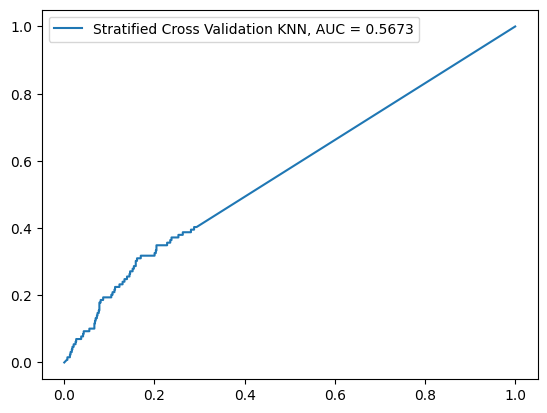

In [64]:
from sklearn.model_selection import train_test_split
X = df1.drop("TenYearCHD", axis = 1)
y = df1["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scale only continuous features, leave binary as-is
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()
X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

k_values = range(3, 21, 2)
recall_scores = []

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

for k in k_values:
  knn = KNN(n_neighbors = k, weights = 'distance')
  score = cross_val_score(knn, X_train, y_train, cv = cv, scoring = 'recall')
  recall_scores.append(score.mean())

plt.plot(k_values, recall_scores)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("CV Recall")
plt.show()

# Select best k value
best_k = k_values[np.argmax(recall_scores)]
print("Best k:", best_k)

# Train model for best k value
knn_classifier_final = KNN(n_neighbors = best_k, weights = 'distance')
knn_classifier_final.fit(X_train, y_train)

# Predictions
y_pred = knn_classifier_final.predict(X_test)
y_prob = knn_classifier_final.predict_proba(X_test)[:,-1]

print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report: ")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "Stratified Cross Validation KNN, AUC = "+str(auc))
plt.legend()

# **KNN with SMOTE:**

Confusion Matrix:
[[475 244]
 [ 66  63]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75       719
           1       0.21      0.49      0.29       129

    accuracy                           0.63       848
   macro avg       0.54      0.57      0.52       848
weighted avg       0.78      0.63      0.68       848

Accuracy: 0.6344339622641509
Precision: 0.20521172638436483
Recall: 0.4883720930232558
F1 Score: 0.2889908256880734
ROC-AUC Score: 0.601535293420017


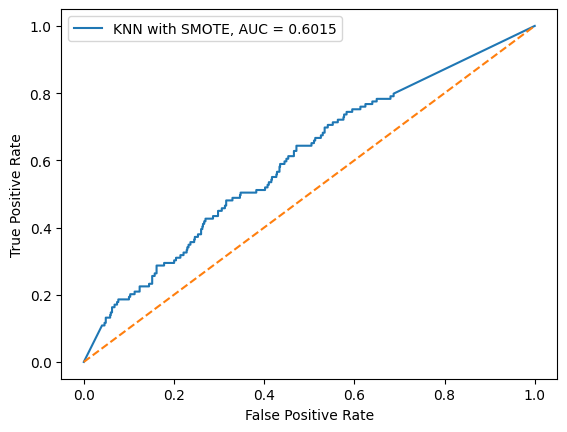

In [65]:
# Train–Test Split
from sklearn.model_selection import train_test_split
X = df1.drop("TenYearCHD", axis=1)
y = df1["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scaling (Train only)
from sklearn.preprocessing import MinMaxScaler
numericalcols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = MinMaxScaler()

X_train[numericalcols] = scaler.fit_transform(X_train[numericalcols])
X_test[numericalcols] = scaler.transform(X_test[numericalcols])

# Apply SMOTE (Train only)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# Train KNN Model
from sklearn.neighbors import KNeighborsClassifier as KNN
knn_smote = KNN(n_neighbors=7,weights='distance')
knn_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = knn_smote.predict(X_test)
y_prob = knn_smote.predict_proba(X_test)[:, 1]

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ROC Curve
from sklearn import metrics
import matplotlib.pyplot as plt

fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)

plt.plot(fpr, tpr, label="KNN with SMOTE, AUC = " + str(auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# **XGBoost Classifier:**

Confusion Matrix: 
[[552 167]
 [ 73  56]] 

Classification Report: 
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       719
           1       0.25      0.43      0.32       129

    accuracy                           0.72       848
   macro avg       0.57      0.60      0.57       848
weighted avg       0.79      0.72      0.74       848

Accuracy score:0.7169811320754716
Precision score:0.25112107623318386
Recall score:0.43410852713178294
F1 score:0.3181818181818182
XGBoost ROC-AUC Score: 0.6466884454075967


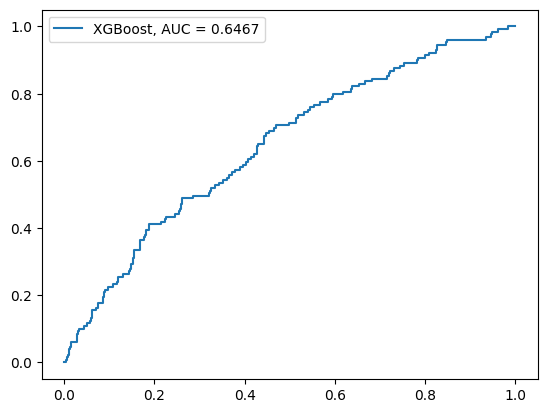

In [66]:
# Train–Test Split
from sklearn.model_selection import train_test_split
X = df1.drop("TenYearCHD", axis=1)
y = df1["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Train model
from xgboost import XGBClassifier
xgb_classifier = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 5, objective = 'binary:logistic',
                               scale_pos_weight = 5.57, eval_metric = 'auc', random_state = 42)
xgb_classifier.fit(X_train, y_train)

# n_estimators = Number of trees to build
# learning_rate = Step size shrinkage (prevent overfitting)
# max_depth= Maximum tree depth
# objective='binary:logistic' = Output probabilities for binary labels

# Predict
y_pred = xgb_classifier.predict(X_test)
y_prob = xgb_classifier.predict_proba(X_test)[:,-1]

from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred), "\n")
print("Classification Report: ")
print(classification_report(y_test, y_pred))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy score:" +str(accuracy_score(y_test,y_pred)))
print("Precision score:" +str(precision_score(y_test,y_pred)))
print("Recall score:" +str(recall_score(y_test,y_pred)))
print("F1 score:" +str(f1_score(y_test,y_pred)))

# ROC-AUC Curve (Receiver operating characteristic - Area under curve)
from sklearn.metrics import roc_auc_score
xgb_roc_score = roc_auc_score(y_test, y_prob)
print("XGBoost ROC-AUC Score: " +str(xgb_roc_score))

from sklearn import metrics
xgb_probabilities = xgb_classifier.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
auc = round(metrics.roc_auc_score(y_test, y_prob), 4)
plt.plot(fpr,tpr,label = "XGBoost, AUC = "+str(auc))
plt.legend()

## **Why KNN Imputation Was Not Used**

- KNN imputation was explored to handle missing values (notably ~9% missing in glucose) because it can leverage similarities between patients and relationships among health indicators. However, it was not included in the final pipeline because:
1. No meaningful performance gain over median/mode imputation in recall or ROC-AUC.
2. Simpler methods improve interpretability, which is important in healthcare risk modeling.
3. Logistic regression performs reliably with robust central-tendency imputations.
4. Reduced complexity improves reproducibility and deployment readiness.

Therefore, median imputation (numerical) and mode imputation (categorical) were retained to balance performance, transparency, and practical usability.